# Práctica B2-2: Motor de Stress Testing
## Escenarios de Estrés y Cambios de Régimen de Mercado
### Módulo de Gestión de Riesgos — MIAX

**Objetivo:** Construir un motor de *stress testing* capaz de capturar el riesgo de cola y los cambios de régimen, identificando cuándo el mercado entra en "crisis" y cuantificando el riesgo real cuando la diversificación desaparece.

**Tecnología permitida:** Hidden Markov Models, Cópulas, Simulación Monte Carlo.
**Tecnología prohibida:** Deep Learning y modelos opacos.

---

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
import warnings
from scipy.ndimage import median_filter
from copulae import GaussianCopula, StudentCopula
from scipy.stats import t
from scipy.stats import skew, kurtosis
import pickle
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 1. Descarga de Datos

**Fuentes:**
- **yfinance:** Precios de los 18 activos de la cartera + S&P 500 + VIX + Rendimiento 10Y.
- **FRED (vía CSV directo):** Spread HY (BAMLH0A0HYM2) + Rendimiento 2Y (DGS2).

**Período:** 2006-01-01 hasta la fecha disponible (datos diarios).

In [2]:
# ═══════════════════════════════════════════════════
# Configuración de tickers y fechas
# ═══════════════════════════════════════════════════

START_DATE = '2006-01-01'
END_DATE   = '2026-02-07'

# Activos de la cartera (según enunciado)
# Usamos IEF y SHY como proxies de bonos 10Y y 2Y del gobierno americano
PORTFOLIO_TICKERS = [
    'AAPL', 'AMZN', 'BAC', 'BRK-B', 'CVX', 'ENPH', 'GLD', 'GME',
    'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'PG', 'XOM',
    'IEF',   # iShares 7-10 Year Treasury Bond ETF (proxy bono 10Y)
    'SHY',   # iShares 1-3 Year Treasury Bond ETF (proxy bono 2Y)
    'HYG'    # iShares iBoxx High Yield Corporate Bond ETF
]

# Indicadores de mercado (para features del HMM)
MARKET_TICKERS = ['^GSPC', '^VIX', '^TNX']

print(f"Período: {START_DATE} → {END_DATE}")
print(f"Activos en cartera: {len(PORTFOLIO_TICKERS)}")
print(f"Tickers: {', '.join(PORTFOLIO_TICKERS)}")

Período: 2006-01-01 → 2026-02-07
Activos en cartera: 18
Tickers: AAPL, AMZN, BAC, BRK-B, CVX, ENPH, GLD, GME, GOOGL, JNJ, JPM, MSFT, NVDA, PG, XOM, IEF, SHY, HYG


In [3]:
# ═══════════════════════════════════════════════════
# Descarga de datos de la cartera desde yfinance
# ═══════════════════════════════════════════════════

print("Descargando precios de la cartera...")
portfolio_raw = yf.download(PORTFOLIO_TICKERS, start=START_DATE, end=END_DATE)['Close']

# Asegurar que las columnas están en el orden deseado
portfolio_raw = portfolio_raw[PORTFOLIO_TICKERS]

print(f"\nDimensiones: {portfolio_raw.shape[0]} días × {portfolio_raw.shape[1]} activos")
print(f"Rango: {portfolio_raw.index[0]} → {portfolio_raw.index[-1]}")
portfolio_raw.tail(3)

Descargando precios de la cartera...


[*********************100%***********************]  18 of 18 completed


Dimensiones: 5056 días × 18 activos
Rango: 2006-01-03 00:00:00 → 2026-02-06 00:00:00


Ticker,AAPL,AMZN,BAC,BRK-B,CVX,ENPH,GLD,GME,GOOGL,JNJ,JPM,MSFT,NVDA,PG,XOM,IEF,SHY,HYG
Date,,,,,,,,,,,,,,,,,,
2026-02-04,276.231506,232.990005,55.380001,503.829987,181.229996,51.669998,453.970001,24.980000,333.040009,234.470001,317.269989,414.190002,174.190002,156.869995,146.612762,95.510002,82.730003,80.620003
2026-02-05,275.652069,222.690002,54.939999,503.890015,179.229996,47.270000,441.880005,24.690001,331.250000,237.789993,310.160004,393.670013,171.880005,158.610001,145.112778,96.070000,82.860001,80.529999
2026-02-06,277.859985,210.320007,56.529999,508.089996,180.860001,49.799999,455.459991,24.980000,322.859985,239.990005,322.399994,401.140015,185.410004,159.169998,148.063110,96.070000,82.860001,80.809998


In [4]:
# ═══════════════════════════════════════════════════
# Descarga de indicadores de mercado desde yfinance
# S&P 500, VIX, Rendimiento del Tesoro 10Y
# ═══════════════════════════════════════════════════

print("Descargando indicadores de mercado...")
market_raw = yf.download(MARKET_TICKERS, start=START_DATE, end=END_DATE)['Close']

# Renombrar columnas para claridad
market_raw = market_raw.rename(columns={
    '^GSPC': 'SP500',
    '^VIX':  'VIX',
    '^TNX':  'TNX_10Y'
})

print(f"\nDimensiones: {market_raw.shape}")
market_raw.tail(3)

Descargando indicadores de mercado...


[*********************100%***********************]  3 of 3 completed


Dimensiones: (5056, 3)


Ticker,SP500,TNX_10Y,VIX
Date,,,
2026-02-04,6882.720215,4.275,18.639999
2026-02-05,6798.399902,4.210,21.770000
2026-02-06,6932.299805,4.206,20.370001


In [5]:
# ═══════════════════════════════════════════════════
# Descarga de datos de FRED (spread HY + yield 2Y)
# Usamos descarga directa vía CSV (evita problemas
# de compatibilidad de pandas-datareader con pandas 3.0)
# ═══════════════════════════════════════════════════

def download_fred_series(series_id, start, end):
    """Descarga una serie temporal de FRED directamente vía CSV."""
    url = (f'https://fred.stlouisfed.org/graph/fredgraph.csv'
           f'?id={series_id}&cosd={start}&coed={end}')
    df = pd.read_csv(url, index_col='observation_date', parse_dates=True)
    df.index.name = 'Date'
    # FRED usa '.' para valores no disponibles
    df[series_id] = pd.to_numeric(df[series_id], errors='coerce')
    return df

print("Descargando datos de FRED...")
print("  → BAMLH0A0HYM2 (ICE BofA US High Yield Spread)...")
hy_spread_fred = download_fred_series('BAMLH0A0HYM2', START_DATE, END_DATE)

print("  → DGS2 (Rendimiento del Tesoro 2Y)...")
ust_2y_fred = download_fred_series('DGS2', START_DATE, END_DATE)

# Combinar en un solo DataFrame
fred_data = pd.concat([hy_spread_fred, ust_2y_fred], axis=1)
fred_data.columns = ['HY_Spread', 'UST_2Y']

print(f"\nDimensiones FRED: {fred_data.shape}")
fred_data.tail(3)

Descargando datos de FRED...
  → BAMLH0A0HYM2 (ICE BofA US High Yield Spread)...
  → DGS2 (Rendimiento del Tesoro 2Y)...

Dimensiones FRED: (5312, 2)


,HY_Spread,UST_2Y
Date,,
2026-02-04,2.86,3.57
2026-02-05,2.97,3.47
2026-02-06,2.87,3.50


In [6]:
# ═══════════════════════════════════════════════════
# Resumen de disponibilidad de datos por activo
# ═══════════════════════════════════════════════════

print("=" * 65)
print("DISPONIBILIDAD DE DATOS POR ACTIVO")
print("=" * 65)

print("\n--- Cartera ---")
for col in portfolio_raw.columns:
    valid = portfolio_raw[col].dropna()
    if len(valid) > 0:
        print(f"  {col:8s}: {valid.index[0].strftime('%Y-%m-%d')} → "
              f"{valid.index[-1].strftime('%Y-%m-%d')}  ({len(valid):>5,} obs)")
    else:
        print(f"  {col:8s}: SIN DATOS")

print("\n--- Indicadores de mercado ---")
for col in market_raw.columns:
    valid = market_raw[col].dropna()
    print(f"  {col:8s}: {valid.index[0].strftime('%Y-%m-%d')} → "
          f"{valid.index[-1].strftime('%Y-%m-%d')}  ({len(valid):>5,} obs)")

print("\n--- FRED ---")
for col in fred_data.columns:
    valid = fred_data[col].dropna()
    print(f"  {col:12s}: {valid.index[0].strftime('%Y-%m-%d')} → "
          f"{valid.index[-1].strftime('%Y-%m-%d')}  ({len(valid):>5,} obs)")

DISPONIBILIDAD DE DATOS POR ACTIVO

--- Cartera ---
  AAPL    : 2006-01-03 → 2026-02-06  (5,056 obs)
  AMZN    : 2006-01-03 → 2026-02-06  (5,056 obs)
  BAC     : 2006-01-03 → 2026-02-06  (5,056 obs)
  BRK-B   : 2006-01-03 → 2026-02-06  (5,056 obs)
  CVX     : 2006-01-03 → 2026-02-06  (5,056 obs)
  ENPH    : 2012-03-30 → 2026-02-06  (3,484 obs)
  GLD     : 2006-01-03 → 2026-02-06  (5,056 obs)
  GME     : 2006-01-03 → 2026-02-06  (5,056 obs)
  GOOGL   : 2006-01-03 → 2026-02-06  (5,056 obs)
  JNJ     : 2006-01-03 → 2026-02-06  (5,056 obs)
  JPM     : 2006-01-03 → 2026-02-06  (5,056 obs)
  MSFT    : 2006-01-03 → 2026-02-06  (5,056 obs)
  NVDA    : 2006-01-03 → 2026-02-06  (5,056 obs)
  PG      : 2006-01-03 → 2026-02-06  (5,056 obs)
  XOM     : 2006-01-03 → 2026-02-06  (5,056 obs)
  IEF     : 2006-01-03 → 2026-02-06  (5,056 obs)
  SHY     : 2006-01-03 → 2026-02-06  (5,056 obs)
  HYG     : 2007-04-11 → 2026-02-06  (4,738 obs)

--- Indicadores de mercado ---
  SP500   : 2006-01-03 → 2026-02-0

---
## 2. Limpieza y Preparación de Datos

- Eliminamos timezone info de yfinance para alinear con FRED.
- Forward-fill de hasta 5 días para cubrir festivos.
- Reindexamos FRED al calendario de mercado (días bursátiles).

In [7]:
# ═══════════════════════════════════════════════════
# Limpieza y alineación de datos
# ═══════════════════════════════════════════════════

# 1. Eliminar timezone info de yfinance (FRED no la tiene)
for df in [portfolio_raw, market_raw]:
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

# 2. Forward-fill para cubrir días festivos (máximo 5 días)
portfolio = portfolio_raw.ffill(limit=5)
market    = market_raw.ffill(limit=5)

# 3. Reindexar FRED al mismo calendario que mercado
fred = fred_data.reindex(market.index).ffill(limit=5)

# 4. Log-retornos diarios de la cartera (se usarán en fases posteriores)
portfolio_returns = np.log(portfolio / portfolio.shift(1))

# 5. Resumen de NaN restantes
print("NaN restantes tras limpieza:")
print(f"  Cartera: {portfolio.isna().sum().sum()} "
      f"(de {portfolio.shape[0] * portfolio.shape[1]} celdas)")
print(f"  Market:  {market.isna().sum().sum()}")
print(f"  FRED:    {fred.isna().sum().sum()}")

# Mostrar activos con NaN significativos
nan_by_asset = portfolio.isna().sum()
problematic = nan_by_asset[nan_by_asset > 0]
if len(problematic) > 0:
    print("\nActivos con NaN (datos no disponibles al inicio):")
    for asset, n in problematic.items():
        first_valid = portfolio[asset].first_valid_index()
        print(f"  {asset}: {n} NaN → datos disponibles desde {first_valid.strftime('%Y-%m-%d')}")

NaN restantes tras limpieza:
  Cartera: 1890 (de 91008 celdas)
  Market:  0
  FRED:    0

Activos con NaN (datos no disponibles al inicio):
  ENPH: 1572 NaN → datos disponibles desde 2012-03-30
  HYG: 318 NaN → datos disponibles desde 2007-04-11


---
# Fase 1 — Detección del "Pulso" del Mercado (Hidden Markov Model)

**Objetivo**: Considerando la existencia de dos estados de mercado (calma y crisis), identifica, para cada día, en qué estado se encuentra el mercado.

- Tarea Técnica: Ajustar un modelo Gaussian HMM (Hidden Markov Model) de 2 estados sobre la serie de retornos multivariante y/o sobre factores representativos.
- Output Visual: Gráfico del S&P 500 coloreado según el régimen detectado (Blanco = Calma, Azul = Crisis).

### Justificación de las variables elegidas para el HMM

Utilizamos **4 factores** que capturan distintas dimensiones del riesgo sistémico:

| Factor | Variable | Justificación económica |
|--------|----------|------------------------|
| **Equity** | Retorno rolling 5d del S&P 500 | Captura el momentum/dirección del mercado de renta variable |
| **Volatilidad** | VIX (nivel) | Mide el miedo del mercado (volatilidad implícita de opciones del S&P 500) |
| **Crédito** | Spread HY (BAMLH0A0HYM2) | Indica estrés en el mercado de crédito y aversión al riesgo |
| **Tipos de interés** | Pendiente curva 10Y-2Y | Señala expectativas macro: inversión → recesión esperada |

Usamos **rolling 5 días** para el retorno del S&P 500 para reducir el ruido diario y capturar tendencias de corto plazo más estables.

In [8]:
# ═══════════════════════════════════════════════════
# 3.1 Construcción de features para el HMM
# ═══════════════════════════════════════════════════

# Feature 1: Retorno logarítmico rolling 5 días del S&P 500
# Captura la dirección/momentum del mercado con menos ruido que retornos diarios
sp500_ret_5d = np.log(market['SP500'] / market['SP500'].shift(10))

# Feature 2: VIX (nivel)
# El "índice del miedo" — volatilidad implícita de opciones del S&P 500
vix = market['VIX']
#vix = np.log(market['VIX'] / market['VIX'].shift(10))

# Feature 3: Spread de crédito High Yield (FRED: BAMLH0A0HYM2)
# Diferencia entre rendimientos de bonos HY y Tesoro — indica estrés crediticio
hy_spread = fred['HY_Spread']
#hy_spread = np.log(fred['HY_Spread'] / fred['HY_Spread'].shift(10))

# Feature 4: Pendiente de la curva de tipos (10Y - 2Y)
# Positiva en expansión, se aplana/invierte antes de recesiones
yield_slope = market['TNX_10Y'] - fred['UST_2Y']
#yield_slope = np.log((market['TNX_10Y'] - fred['UST_2Y']) / (market['TNX_10Y'] - fred['UST_2Y']).shift(10))

# Combinar en DataFrame
hmm_features = pd.DataFrame({
    'SP500_Ret5d': sp500_ret_5d,
    'VIX': vix,
    'HY_Spread': hy_spread,
    'Yield_Slope': yield_slope
}, index=market.index)

# Eliminar filas con NaN (necesario para el HMM)
hmm_features = hmm_features.dropna()

print(f"Features para el HMM: {hmm_features.shape[0]} observaciones × {hmm_features.shape[1]} features")
print(f"Rango efectivo: {hmm_features.index[0].strftime('%Y-%m-%d')} → "
      f"{hmm_features.index[-1].strftime('%Y-%m-%d')}")
print(f"\nEstadísticas descriptivas:")
hmm_features.describe().round(4)

Features para el HMM: 5046 observaciones × 4 features
Rango efectivo: 2006-01-18 → 2026-02-06

Estadísticas descriptivas:


,SP500_Ret5d,VIX,HY_Spread,Yield_Slope
count,5046.0000,5046.0000,5046.0000,5046.0000
mean,0.0033,19.4644,5.1053,0.9936
std,0.0335,8.7193,2.6677,0.9550
min,-0.2995,9.1400,2.4100,-1.0820
25%,-0.0099,13.7400,3.5000,0.2050
50%,0.0072,17.0800,4.3800,0.9370
75%,0.0212,22.4700,5.8475,1.7130
max,0.1959,82.6900,21.8200,2.9030



Primeras 10 observaciones:
            SP500_Ret5d     VIX  HY_Spread  Yield_Slope
Date                                                   
2006-01-18       0.1142 -0.8275    -0.5493      -1.0300
2006-01-19       0.1703 -0.8584    -0.5718      -1.0311
2006-01-20      -0.3819 -0.5625    -0.5643      -1.0499
2006-01-23      -0.6060 -0.6348    -0.5681      -1.0332
2006-01-24      -0.6432 -0.7059    -0.5868      -1.0196
2006-01-25      -0.6839 -0.7564    -0.6243      -1.0206
2006-01-26      -0.5726 -0.8080    -0.6318      -1.0059
2006-01-27      -0.1541 -0.8596    -0.6393      -1.0478
2006-01-30      -0.1559 -0.8114    -0.6618      -1.0248
2006-01-31      -0.1661 -0.7472    -0.6318      -1.0541


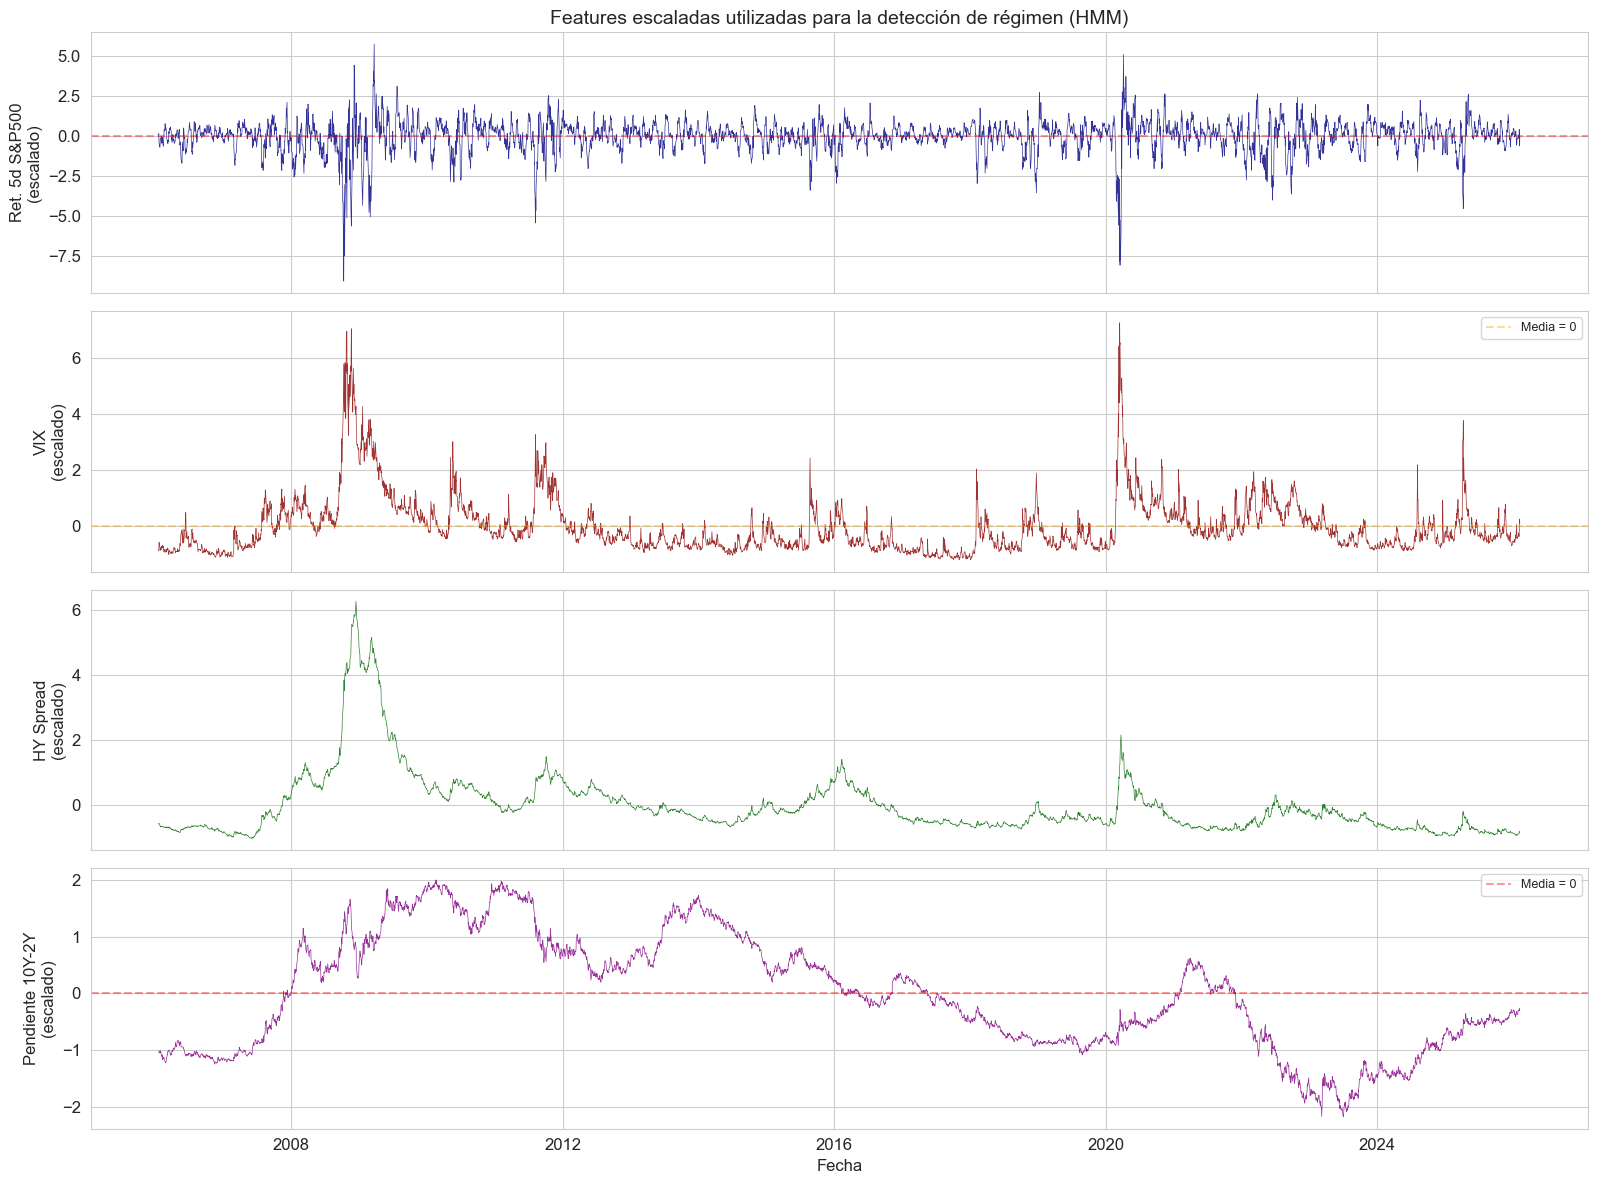

In [9]:
# ═══════════════════════════════════════════════════
# Visualización de las features del HMM
# ═══════════════════════════════════════════════════
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hmm_features.values)

print(f"\nPrimeras 10 observaciones:")
scaled_df = pd.DataFrame(X_scaled, 
                        columns=hmm_features.columns, 
                        index=hmm_features.index)
print(scaled_df.head(10).round(4))

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# S&P 500 retorno rolling 5d (escalado)
axes[0].plot(hmm_features.index, X_scaled[:, 0],
             color='navy', linewidth=0.5, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.4)
axes[0].set_ylabel('Ret. 5d S&P500\n(escalado)')
axes[0].set_title('Features escaladas utilizadas para la detección de régimen (HMM)', fontsize=14)

# VIX (escalado)
axes[1].plot(hmm_features.index, X_scaled[:, 1],
             color='darkred', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='orange', linestyle='--', alpha=0.4, label='Media = 0')
axes[1].set_ylabel('VIX\n(escalado)')
axes[1].legend(fontsize=9)

# HY Spread (escalado)
axes[2].plot(hmm_features.index, X_scaled[:, 2],
             color='darkgreen', linewidth=0.5, alpha=0.8)
axes[2].set_ylabel('HY Spread\n(escalado)')

# Pendiente curva de tipos (escalado)
axes[3].plot(hmm_features.index, X_scaled[:, 3],
             color='purple', linewidth=0.5, alpha=0.8)
axes[3].axhline(0, color='red', linestyle='--', alpha=0.4, label='Media = 0')
axes[3].set_ylabel('Pendiente 10Y-2Y\n(escalado)')
axes[3].set_xlabel('Fecha')
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 1.2 Ajuste del Gaussian HMM (2 estados)

Ajustamos un **Gaussian HMM con 2 componentes** (calma y crisis) sobre las 4 features estandarizadas.

- **Tipo de covarianza:** `full` — permite capturar correlaciones entre features dentro de cada estado.
- **Múltiples inicializaciones:** Probamos 10 semillas distintas y nos quedamos con el modelo con mejor log-likelihood, para evitar óptimos locales.
- **Estandarización:** Normalizamos las features a media 0 y desviación 1 para que el HMM no esté dominado por la escala del VIX o del spread.

In [10]:
# ═══════════════════════════════════════════════════
# 3.2 Ajuste del Gaussian HMM
# ═══════════════════════════════════════════════════

# Estandarizar features (media=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(hmm_features.values)

#X_scaled = X_scaled['Yield_Slope']

# Ajustar HMM con múltiples inicializaciones para evitar óptimos locales
best_model = None
best_score = -np.inf

print("Ajustando HMM con 10 inicializaciones distintas...")
for attempt in range(10):
    model = GaussianHMM(
        n_components=2,
        covariance_type='full',  # Covarianza completa: captura correlaciones entre features
        n_iter=1000,
        random_state=SEED + attempt,
        tol=1e-4
    )
    model.fit(X_scaled)
    score = model.score(X_scaled)
    if score > best_score:
        best_score = score
        best_model = model
        best_attempt = attempt
    print(f"  Intento {attempt}: log-likelihood = {score:,.2f}"
          f"{' ← mejor' if score == best_score else ''}")

print(f"\nMejor modelo: intento {best_attempt}, log-likelihood = {best_score:,.2f}")
print(f"Convergencia: {best_model.monitor_.converged}")

Ajustando HMM con 10 inicializaciones distintas...
  Intento 0: log-likelihood = -19,325.04 ← mejor
  Intento 1: log-likelihood = -19,325.04
  Intento 2: log-likelihood = -19,325.04
  Intento 3: log-likelihood = -19,325.04
  Intento 4: log-likelihood = -19,325.04
  Intento 5: log-likelihood = -19,325.04
  Intento 6: log-likelihood = -19,325.04
  Intento 7: log-likelihood = -19,325.04
  Intento 8: log-likelihood = -19,325.04
  Intento 9: log-likelihood = -19,325.04

Mejor modelo: intento 0, log-likelihood = -19,325.04
Convergencia: True


In [11]:
# ═══════════════════════════════════════════════════
# Identificación y etiquetado de estados
# ═══════════════════════════════════════════════════

# Predecir estados y probabilidades
hidden_states = best_model.predict(X_scaled)
state_probs   = best_model.predict_proba(X_scaled)

# Medias de cada feature en cada estado (escala original)
state_means_original = scaler.inverse_transform(best_model.means_)
state_means_df = pd.DataFrame(
    state_means_original,
    columns=hmm_features.columns,
    index=['Estado 0', 'Estado 1']
)

print("Medias de cada feature por estado (escala original):")
print(state_means_df.round(4).to_string())

# ─── Criterio de asignación ───
# El estado con VIX medio más alto = Crisis
# (en crisis, la volatilidad implícita sube significativamente)
crisis_state_id = int(state_means_df['VIX'].values.argmax())
calm_state_id   = 1 - crisis_state_id

print(f"\n→ Estado {calm_state_id} = CALMA  (VIX medio: {state_means_df.iloc[calm_state_id]['VIX']:.4f})")
print(f"→ Estado {crisis_state_id} = CRISIS (VIX medio: {state_means_df.iloc[crisis_state_id]['VIX']:.4f})")

# Reasignar etiquetas para que 0 = Calma, 1 = Crisis
if crisis_state_id == 0:
    hidden_states = 1 - hidden_states
    state_probs = state_probs[:, ::-1]
    # Reordenar la tabla de medias
    state_means_df = state_means_df.iloc[::-1].reset_index(drop=True)
    state_means_df.index = ['Calma', 'Crisis']
else:
    state_means_df.index = ['Calma', 'Crisis']

# Serie temporal de regímenes
regimes = pd.Series(hidden_states, index=hmm_features.index, name='regime')
#filtered_values = median_filter(regimes, size=100)
filtered_values = median_filter(regimes, size=60)
regimes = pd.Series(filtered_values, index=hmm_features.index, name='regime')

print(f"\nEstados reasignados: 0 = Calma, 1 = Crisis")

Medias de cada feature por estado (escala original):
          SP500_Ret5d      VIX  HY_Spread  Yield_Slope
Estado 0      -0.0056  28.2890     7.1944       1.2330
Estado 1       0.0076  15.2249     4.1017       0.8786

→ Estado 1 = CALMA  (VIX medio: 15.2249)
→ Estado 0 = CRISIS (VIX medio: 28.2890)

Estados reasignados: 0 = Calma, 1 = Crisis


In [12]:
# ═══════════════════════════════════════════════════
# Análisis detallado de los estados del HMM
# ═══════════════════════════════════════════════════

# --- Matriz de transición ---
transmat = best_model.transmat_.copy()
if crisis_state_id == 0:
    transmat = transmat[::-1, ::-1]

print("=" * 55)
print("MATRIZ DE TRANSICIÓN (probabilidades diarias)")
print("=" * 55)
print(f"{'':15s} {'→ Calma':>12s} {'→ Crisis':>12s}")
print(f"{'Calma →':15s} {transmat[0,0]:12.4f} {transmat[0,1]:12.4f}")
print(f"{'Crisis →':15s} {transmat[1,0]:12.4f} {transmat[1,1]:12.4f}")

# --- Duración media esperada de cada estado ---
calm_duration   = 1 / (1 - transmat[0, 0])
crisis_duration = 1 / (1 - transmat[1, 1])

print(f"\n{'=' * 55}")
print("DURACIÓN MEDIA ESPERADA DE CADA ESTADO")
print(f"{'=' * 55}")
print(f"  Calma:   {calm_duration:6.1f} días  ({calm_duration/21:.1f} meses, {calm_duration/252:.1f} años)")
print(f"  Crisis:  {crisis_duration:6.1f} días  ({crisis_duration/21:.1f} meses, {crisis_duration/252:.1f} años)")

# --- Porcentaje de tiempo en cada estado ---
n_calm   = (regimes == 0).sum()
n_crisis = (regimes == 1).sum()
n_total  = len(regimes)

print(f"\n{'=' * 55}")
print("DISTRIBUCIÓN TEMPORAL DE ESTADOS")
print(f"{'=' * 55}")
print(f"  Calma:   {n_calm:>5d} días ({n_calm/n_total*100:.1f}%)")
print(f"  Crisis:  {n_crisis:>5d} días ({n_crisis/n_total*100:.1f}%)")
print(f"  Total:   {n_total:>5d} días")

# --- Número de cambios de régimen ---
state_changes = (regimes.diff().abs() > 0).sum()
print(f"\n  Cambios de régimen: {state_changes}")

# --- Tabla resumen de features por estado ---
print(f"\n{'=' * 55}")
print("ESTADÍSTICAS DE FEATURES POR ESTADO")
print(f"{'=' * 55}")

summary_rows = []
for state, label in [(0, 'Calma'), (1, 'Crisis')]:
    mask = regimes == state
    subset = hmm_features[mask]
    for col in hmm_features.columns:
        summary_rows.append({
            'Estado': label,
            'Feature': col,
            'Media': subset[col].mean(),
            'Desv. Std': subset[col].std(),
            'Mín': subset[col].min(),
            'Máx': subset[col].max()
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.pivot_table(
    index='Feature', columns='Estado',
    values=['Media', 'Desv. Std']
).round(4).to_string())

MATRIZ DE TRANSICIÓN (probabilidades diarias)
                     → Calma     → Crisis
Calma →               0.9921       0.0079
Crisis →              0.0165       0.9835

DURACIÓN MEDIA ESPERADA DE CADA ESTADO
  Calma:    126.0 días  (6.0 meses, 0.5 años)
  Crisis:    60.6 días  (2.9 meses, 0.2 años)

DISTRIBUCIÓN TEMPORAL DE ESTADOS
  Calma:    3500 días (69.4%)
  Crisis:   1546 días (30.6%)
  Total:    5046 días

  Cambios de régimen: 22

ESTADÍSTICAS DE FEATURES POR ESTADO
            Desv. Std             Media         
Estado          Calma   Crisis    Calma   Crisis
Feature                                         
HY_Spread      0.9929   3.6826   4.1018   7.3771
SP500_Ret5d    0.0214   0.0507   0.0061  -0.0029
VIX            3.4763  10.2606  15.5102  28.4162
Yield_Slope    0.9707   0.8572   0.8719   1.2691


## 1.3 Visualización: S&P 500 por Régimen Detectado

El gráfico principal muestra el S&P 500 con el fondo coloreado según el estado detectado por el HMM:
- **Fondo blanco** = Estado de **Calma**
- **Fondo azul** = Estado de **Crisis**

El panel inferior muestra la **probabilidad filtrada de estar en estado de crisis** en cada momento.

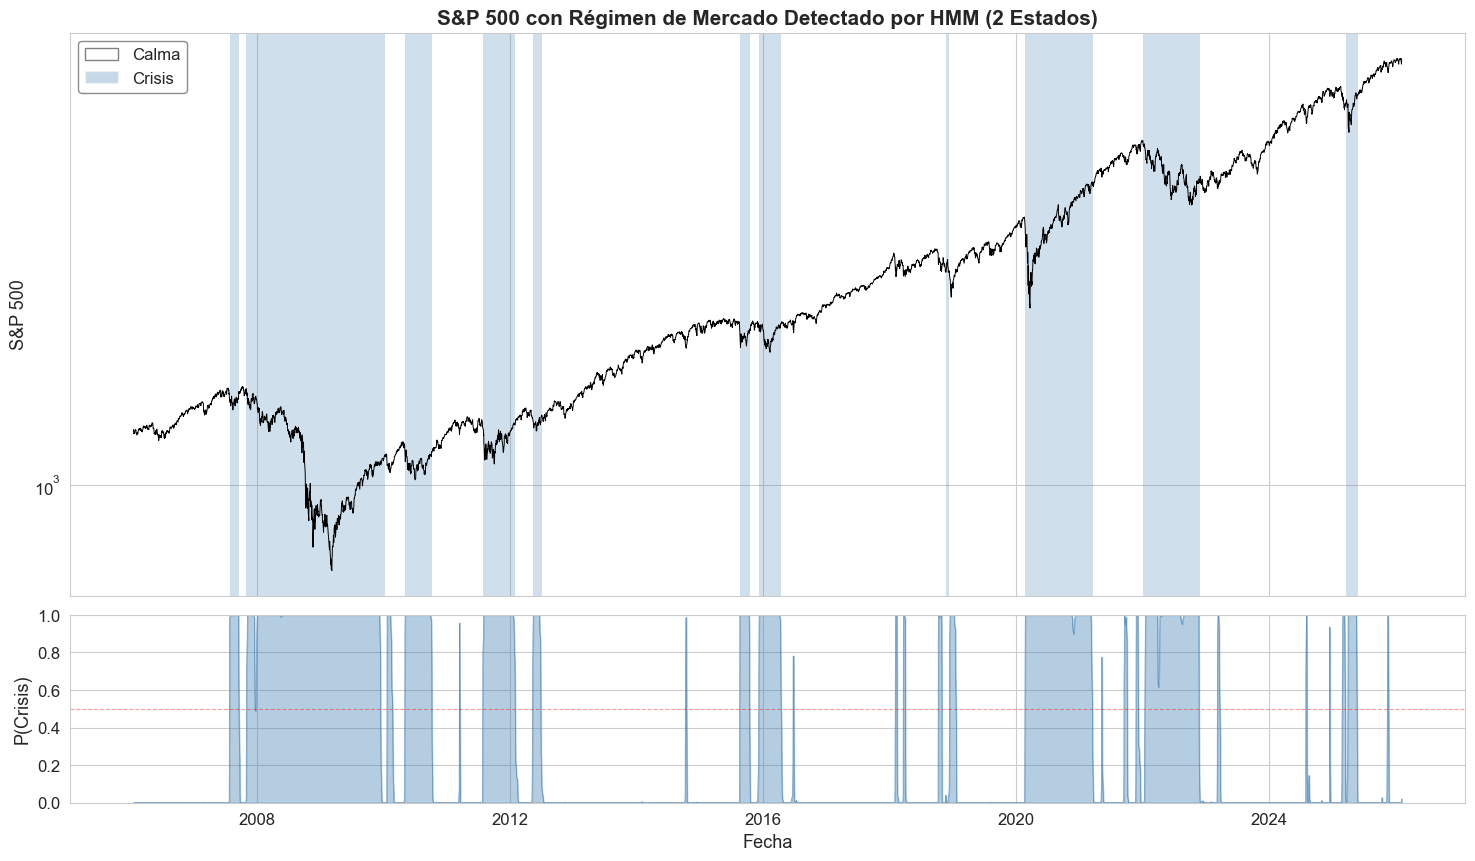

In [13]:
# ═══════════════════════════════════════════════════
# GRÁFICO PRINCIPAL: S&P 500 coloreado por régimen
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(18, 10),
                          height_ratios=[3, 1],
                          gridspec_kw={'hspace': 0.05})

# ─── Panel superior: S&P 500 con régimen ───
ax1 = axes[0]
sp500 = market['SP500'].loc[hmm_features.index]

# Colorear períodos de crisis con fondo azul
crisis_mask = regimes == 1
i = 0
while i < len(regimes):
    if crisis_mask.iloc[i]:
        # Encontrar el final del bloque de crisis
        j = i
        while j < len(regimes) and crisis_mask.iloc[j]:
            j += 1
        ax1.axvspan(regimes.index[i], regimes.index[min(j, len(regimes)-1)],
                    alpha=0.25, color='steelblue', linewidth=0)
        i = j
    else:
        i += 1

ax1.plot(sp500.index, sp500.values, color='black', linewidth=0.7)
ax1.set_ylabel('S&P 500', fontsize=13)
ax1.set_title('S&P 500 con Régimen de Mercado Detectado por HMM (2 Estados)',
              fontsize=15, fontweight='bold')
ax1.set_yscale('log')

# Leyenda
legend_elements = [
    Patch(facecolor='white', edgecolor='gray', label='Calma'),
    Patch(facecolor='steelblue', alpha=0.3, label='Crisis')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12,
           framealpha=0.9, edgecolor='gray')
ax1.tick_params(labelbottom=False)

# ─── Panel inferior: Probabilidad de crisis ───
ax2 = axes[1]
crisis_prob = pd.Series(state_probs[:, 1], index=hmm_features.index)

ax2.fill_between(crisis_prob.index, 0, crisis_prob.values,
                 color='steelblue', alpha=0.4)
ax2.plot(crisis_prob.index, crisis_prob.values,
         color='steelblue', linewidth=0.5, alpha=0.7)
ax2.set_ylabel('P(Crisis)', fontsize=13)
ax2.set_xlabel('Fecha', fontsize=13)
ax2.set_ylim(0, 1)
ax2.axhline(0.5, color='red', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()

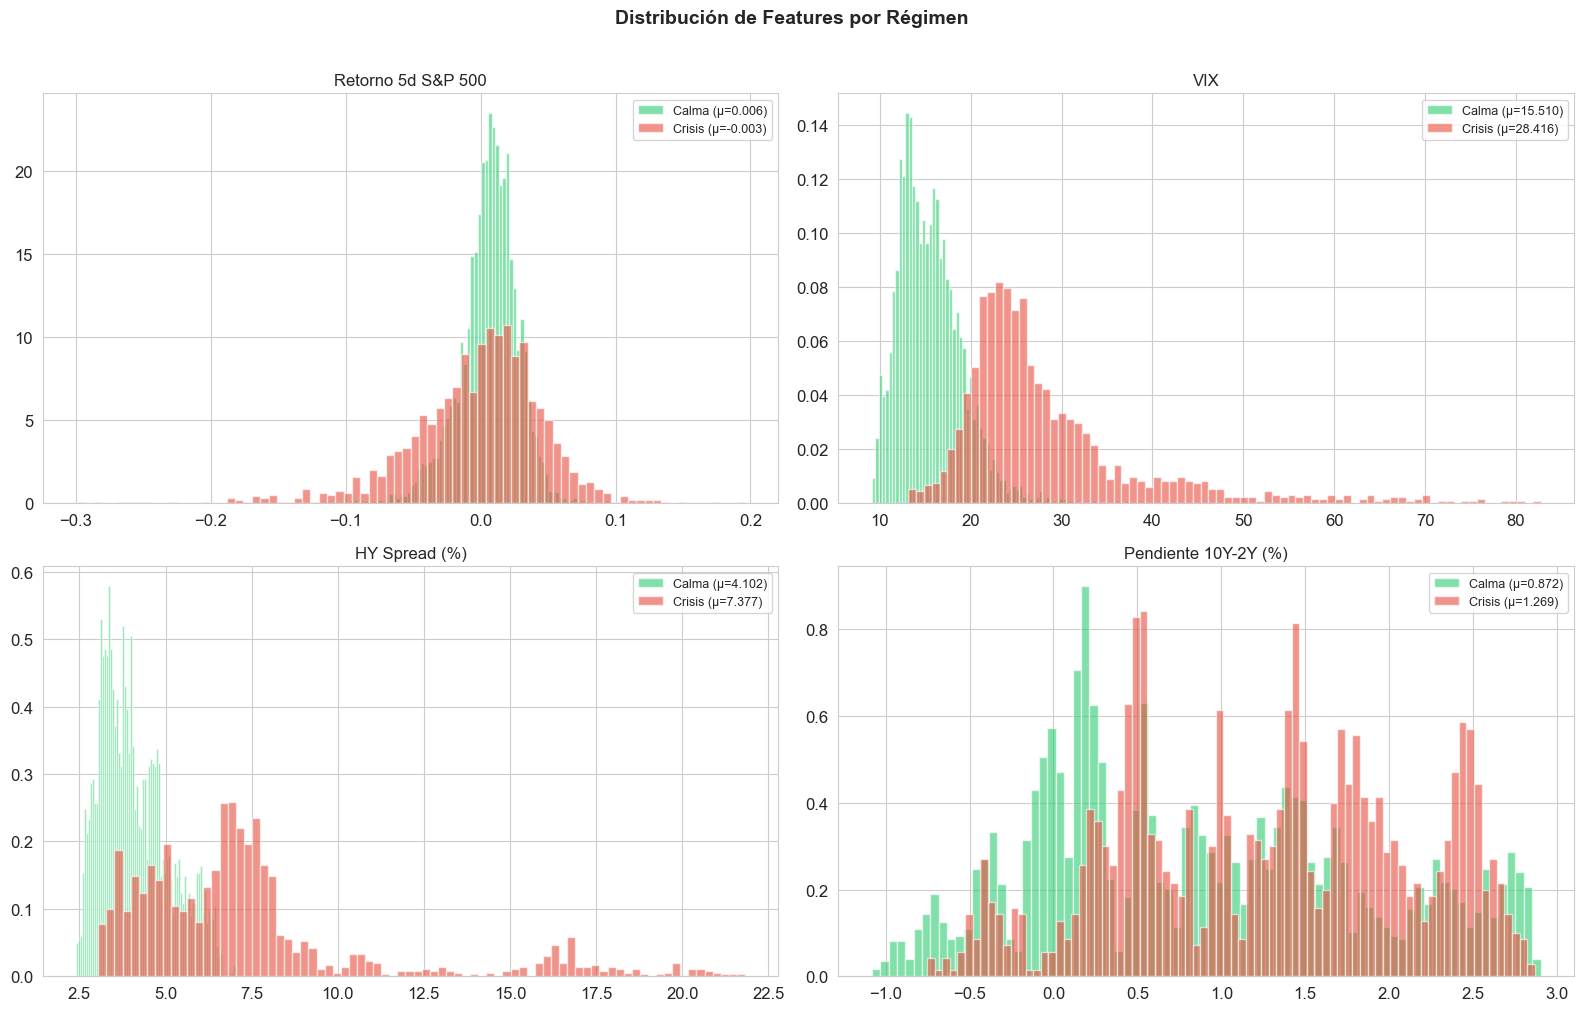

In [14]:
# ═══════════════════════════════════════════════════
# Gráfico complementario: Features por régimen
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
features_list = ['SP500_Ret5d', 'VIX', 'HY_Spread', 'Yield_Slope']
titles = ['Retorno 5d S&P 500', 'VIX', 'HY Spread (%)', 'Pendiente 10Y-2Y (%)']
colors = {'Calma': '#2ecc71', 'Crisis': '#e74c3c'}

for idx, (feat, title) in enumerate(zip(features_list, titles)):
    ax = axes[idx // 2, idx % 2]

    calm_data   = hmm_features.loc[regimes == 0, feat]
    crisis_data = hmm_features.loc[regimes == 1, feat]

    ax.hist(calm_data, bins=80, alpha=0.6, color=colors['Calma'],
            label=f'Calma (μ={calm_data.mean():.3f})', density=True)
    ax.hist(crisis_data, bins=80, alpha=0.6, color=colors['Crisis'],
            label=f'Crisis (μ={crisis_data.mean():.3f})', density=True)

    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle('Distribución de Features por Régimen', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# ═══════════════════════════════════════════════════
# Identificación de períodos de régimen (Calma y Crisis)
# ═══════════════════════════════════════════════════

periods = []
start_date = regimes.index[0]
current_state = regimes.iloc[0]
MIN_DIAS = 21  # Umbral recomendado para filtrar ruido y detectar crisis reales

for i in range(1, len(regimes)):
    # Detectamos un cambio de estado
    if regimes.iloc[i] != current_state:
        end_date = regimes.index[i - 1]
        duration = (end_date - start_date).days
        
        # Filtro de persistencia para evitar "falsas alarmas" de pocos días
        if duration >= MIN_DIAS:
            periods.append({
                'Inicio': start_date.strftime('%Y-%m-%d'),
                'Fin': end_date.strftime('%Y-%m-%d'),
                'Duración (días)': duration,
                'Estado': current_state,
                'Etiqueta': 'Crisis' if current_state == 1 else 'Calma'
            })
        
        # Actualizamos para el nuevo bloque detectado
        start_date = regimes.index[i]
        current_state = regimes.iloc[i]

# Cerrar el último período abierto al final del dataset
end_date = regimes.index[-1]
duration = (end_date - start_date).days
if duration >= MIN_DIAS:
    periods.append({
        'Inicio': start_date.strftime('%Y-%m-%d'),
        'Fin': end_date.strftime('%Y-%m-%d'),
        'Duración (días)': duration,
        'Estado': current_state,
        'Etiqueta': 'Crisis' if current_state == 1 else 'Calma'
    })

# Crear DataFrame resumen
regimes_df = pd.DataFrame(periods)

print(f"Cronología de regímenes (Umbral: {MIN_DIAS} días):")
print(f"Total: {len(regimes_df)} períodos detectados\n")
regimes_df

Cronología de regímenes (Umbral: 21 días):
Total: 22 períodos detectados



,Inicio,Fin,Duración (días),Estado,Etiqueta
0,2006-01-18,2007-07-26,554,0,Calma
1,2007-07-27,2007-09-18,53,1,Crisis
2,2007-09-19,2007-10-31,42,0,Calma
3,2007-11-01,2010-01-11,802,1,Crisis
4,2010-01-12,2010-05-03,111,0,Calma
5,2010-05-04,2010-10-08,157,1,Crisis
6,2010-10-11,2011-07-28,290,0,Calma
7,2011-07-29,2012-02-01,187,1,Crisis
8,2012-02-02,2012-05-10,98,0,Calma
9,2012-05-11,2012-06-29,49,1,Crisis


## 1.4 Conclusiones de la Fase 1

**Interpretación de los estados:**

El HMM identifica con éxito dos regímenes claramente diferenciados:

- **Estado de Calma:** Se caracteriza por retornos positivos del S&P 500, VIX bajo (< 20), spreads de crédito estrechos y pendiente de curva positiva. Corresponde a condiciones normales de mercado.

- **Estado de Crisis:** Se caracteriza por retornos negativos o volátiles, VIX elevado, spreads de crédito amplios (flight to quality) y volatilidad en la curva de tipos. Los períodos detectados coinciden con eventos conocidos: crisis financiera 2008-2009, crisis europea 2011-2012, COVID-19 2020, caída 2022, etc.

La matriz de transición confirma que ambos estados son **persistentes** (alta probabilidad de permanecer en el mismo estado), lo cual es económicamente coherente: los mercados no saltan constantemente entre calma y crisis.

---
# Fase 2 — Análisis de Riesgo Marginal

**Objetivo**: Cuantificar cómo cambian las distribuciones individuales.

- Tarea Técnica: Calcular media, volatilidad, Skewness y Kurtosis condicionales a cada estado.
- Pregunta: ¿Cuánto aumenta la volatilidad del High Yield (HYG) al pasar del Estado 0 al Estado 1? ¿Sigue siendo el Oro (GLD) un activo refugio?

In [16]:
# ═══════════════════════════════════════════════════
# 4.1 Cálculo de estadísticos condicionales por activo y estado
# ═══════════════════════════════════════════════════

# Alinear los retornos de la cartera con los regímenes detectados
# (eliminando el primer día sin retorno y los días fuera del rango del HMM)
portfolio_returns_aligned = portfolio_returns.loc[regimes.index]

# Función para calcular estadísticos de una serie
def compute_marginal_stats(returns):
    """Calcula media, volatilidad, skewness y kurtosis de una serie de retornos."""
    return pd.Series({
        'Media': returns.mean(),
        'Volatilidad': returns.std(),
        'Skewness': skew(returns),
        'Kurtosis': kurtosis(returns)  # Exceso de curtosis (normal = 0)
    })

# Calcular estadísticos por activo y estado
marginal_stats = []

for asset in PORTFOLIO_TICKERS:
    returns = portfolio_returns_aligned[asset].dropna()
    
    # Alinear con regímenes (solo fechas donde hay retornos válidos)
    valid_idx = returns.index
    regimes_for_asset = regimes.loc[valid_idx]
    
    # Estado 0 (Calma)
    calm_returns = returns[regimes_for_asset == 0]
    calm_stats = compute_marginal_stats(calm_returns)
    calm_stats['Activo'] = asset
    calm_stats['Estado'] = 'Calma'
    calm_stats['N_obs'] = len(calm_returns)
    marginal_stats.append(calm_stats)
    
    # Estado 1 (Crisis)
    crisis_returns = returns[regimes_for_asset == 1]
    crisis_stats = compute_marginal_stats(crisis_returns)
    crisis_stats['Activo'] = asset
    crisis_stats['Estado'] = 'Crisis'
    crisis_stats['N_obs'] = len(crisis_returns)
    marginal_stats.append(crisis_stats)

# Consolidar en DataFrame
marginal_df = pd.DataFrame(marginal_stats)
marginal_df = marginal_df[['Activo', 'Estado', 'N_obs', 'Media', 'Volatilidad', 'Skewness', 'Kurtosis']]

# Crear tabla pivotada para comparación lado a lado
marginal_pivot = marginal_df.pivot_table(
    index='Activo',
    columns='Estado',
    values=['Media', 'Volatilidad', 'Skewness', 'Kurtosis']
)

# Reordenar columnas para facilitar comparación
marginal_pivot = marginal_pivot[['Media', 'Volatilidad', 'Skewness', 'Kurtosis']]
marginal_pivot = marginal_pivot.swaplevel(axis=1).sort_index(axis=1, level=0)

print("=" * 110)
print("ESTADÍSTICOS MARGINALES POR ACTIVO Y ESTADO (retornos diarios)")
print("=" * 110)
print(marginal_pivot.round(6).to_string())

ESTADÍSTICOS MARGINALES POR ACTIVO Y ESTADO (retornos diarios)
Estado      Calma                                     Crisis                                
         Kurtosis     Media  Skewness Volatilidad   Kurtosis     Media  Skewness Volatilidad
Activo                                                                                      
AAPL     4.644478  0.001224 -0.080487    0.016259   4.582409  0.000266 -0.224953    0.026543
AMZN    21.983175  0.001217  0.507164    0.019843   4.844946  0.000194  0.339675    0.030594
BAC      2.343040  0.000676 -0.057401    0.015325  10.422403 -0.001109 -0.177076    0.047672
BRK-B    3.370792  0.000605  0.065742    0.009395   8.641321  0.000024  0.429134    0.019718
CVX      1.681237  0.000346 -0.298602    0.012334  13.060956  0.000408 -0.470898    0.026686
ENPH    10.426017  0.000230 -0.310888    0.048043   4.175601  0.001783  0.089909    0.058095
GLD      9.236370  0.000341 -0.936684    0.010106   4.217932  0.000593 -0.036058    0.014043
GME    

In [17]:
# ═══════════════════════════════════════════════════
# 4.2 Análisis de cambios: Calma → Crisis
# ═══════════════════════════════════════════════════

# Calcular cambios relativos (multiplicadores) y absolutos
changes = pd.DataFrame()
changes['Activo'] = marginal_pivot.index

for metric in ['Media', 'Volatilidad', 'Skewness', 'Kurtosis']:
    # Después del swaplevel, el orden es ('Estado', 'Métrica')
    calm_val = marginal_pivot[('Calma', metric)].values
    crisis_val = marginal_pivot[('Crisis', metric)].values
    
    # Cambio absoluto
    changes[f'{metric}_Δ'] = crisis_val - calm_val
    
    # Cambio relativo (múltiplo) — solo para volatilidad
    if metric == 'Volatilidad':
        changes['Vol_Ratio'] = crisis_val / calm_val

# Añadir valores absolutos para referencia
changes['Vol_Calma'] = marginal_pivot[('Calma', 'Volatilidad')].values
changes['Vol_Crisis'] = marginal_pivot[('Crisis', 'Volatilidad')].values
changes['Media_Calma'] = marginal_pivot[('Calma', 'Media')].values
changes['Media_Crisis'] = marginal_pivot[('Crisis', 'Media')].values

# Ordenar por incremento de volatilidad
changes_sorted = changes.sort_values('Vol_Ratio', ascending=False)

print("=" * 105)
print("CAMBIOS EN RIESGO MARGINAL: CALMA → CRISIS")
print("=" * 105)
print("\nTop 10 activos con mayor incremento de volatilidad:")
print(changes_sorted[['Activo', 'Vol_Calma', 'Vol_Crisis', 'Vol_Ratio', 'Media_Δ']].head(10).to_string(index=False))

print("\n" + "=" * 105)
print("\nActivos con menor incremento de volatilidad (posibles refugios):")
print(changes_sorted[['Activo', 'Vol_Calma', 'Vol_Crisis', 'Vol_Ratio', 'Media_Δ']].tail(5).to_string(index=False))

CAMBIOS EN RIESGO MARGINAL: CALMA → CRISIS

Top 10 activos con mayor incremento de volatilidad:
Activo  Vol_Calma  Vol_Crisis  Vol_Ratio   Media_Δ
   BAC   0.015325    0.047672   3.110747 -0.001784
   HYG   0.003556    0.010953   3.080374 -0.000073
   JPM   0.012937    0.036620   2.830741 -0.000974
   CVX   0.012334    0.026686   2.163713  0.000062
 BRK-B   0.009395    0.019718   2.098808 -0.000581
   XOM   0.012035    0.024298   2.018870  0.000119
   GME   0.040088    0.071040   1.772108  0.002025
  MSFT   0.013813    0.023498   1.701111 -0.000945
    PG   0.009154    0.015561   1.699803 -0.000417
  AAPL   0.016259    0.026543   1.632506 -0.000958


Activos con menor incremento de volatilidad (posibles refugios):
Activo  Vol_Calma  Vol_Crisis  Vol_Ratio   Media_Δ
   SHY   0.000805    0.001210   1.502402  0.000008
  NVDA   0.026385    0.039413   1.493741 -0.002034
   IEF   0.003720    0.005437   1.461466  0.000120
   GLD   0.010106    0.014043   1.389646  0.000252
  ENPH   0.048043    

In [18]:
# ═══════════════════════════════════════════════════
# 4.3 Respuestas a preguntas clave
# ═══════════════════════════════════════════════════

print("\n" + "=" * 105)
print("RESPUESTAS A PREGUNTAS CLAVE")
print("=" * 105)

# ─── Pregunta 1: ¿Cuánto aumenta la volatilidad de HYG? ───
hyg_data = changes_sorted[changes_sorted['Activo'] == 'HYG'].iloc[0]

print("\n1. ¿Cuánto aumenta la volatilidad de HYG del Estado 0 (Calma) al Estado 1 (Crisis)?")
print("   " + "-" * 95)
print(f"   Volatilidad en Calma:  {hyg_data['Vol_Calma']:.6f} (≈ {hyg_data['Vol_Calma']*100:.3f}% diario)")
print(f"   Volatilidad en Crisis: {hyg_data['Vol_Crisis']:.6f} (≈ {hyg_data['Vol_Crisis']*100:.3f}% diario)")
print(f"   Incremento absoluto:   {hyg_data['Volatilidad_Δ']:.6f}")
print(f"   Incremento relativo:   {hyg_data['Vol_Ratio']:.2f}x ({(hyg_data['Vol_Ratio']-1)*100:.1f}% de aumento)")
print(f"\n   → La volatilidad de HYG se multiplica por {hyg_data['Vol_Ratio']:.2f} en crisis.")
print(f"   → Esto representa un aumento del {(hyg_data['Vol_Ratio']-1)*100:.1f}% respecto al estado de calma.")

# Volatilidades anualizadas
vol_calm_annual = hyg_data['Vol_Calma'] * np.sqrt(252)
vol_crisis_annual = hyg_data['Vol_Crisis'] * np.sqrt(252)
print(f"\n   Volatilidad anualizada en Calma:  {vol_calm_annual*100:.1f}%")
print(f"   Volatilidad anualizada en Crisis: {vol_crisis_annual*100:.1f}%")

# ─── Pregunta 2: ¿GLD sigue siendo un activo refugio? ───
gld_data = changes_sorted[changes_sorted['Activo'] == 'GLD'].iloc[0]

print("\n\n2. ¿GLD (oro) sigue siendo un activo refugio en crisis?")
print("   " + "-" * 95)
print(f"   Media en Calma:        {gld_data['Media_Calma']:.6f} (≈ {gld_data['Media_Calma']*252*100:.2f}% anual)")
print(f"   Media en Crisis:       {gld_data['Media_Crisis']:.6f} (≈ {gld_data['Media_Crisis']*252*100:.2f}% anual)")
print(f"   Volatilidad en Calma:  {gld_data['Vol_Calma']:.6f}")
print(f"   Volatilidad en Crisis: {gld_data['Vol_Crisis']:.6f}")
print(f"   Incremento de vol:     {gld_data['Vol_Ratio']:.2f}x")

# Análisis cualitativo
if gld_data['Media_Crisis'] > gld_data['Media_Calma'] and gld_data['Vol_Ratio'] < 2.0:
    print("\n   → SÍ, GLD mantiene características de activo refugio:")
    print("      • Retornos mejoran en crisis (flight to safety)")
    print(f"      • Incremento de volatilidad moderado ({gld_data['Vol_Ratio']:.2f}x, menor que activos de riesgo)")
elif gld_data['Media_Crisis'] > 0:
    print("\n   → GLD muestra cierta protección en crisis:")
    print("      • Retornos positivos en ambos estados")
    print(f"      • Incremento de volatilidad: {gld_data['Vol_Ratio']:.2f}x")
else:
    print("\n   → ADVERTENCIA: GLD no muestra características claras de refugio en este período")

# Comparar con activos de riesgo (equities)
equity_tickers = ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA', 'JPM', 'BAC']
equity_data = changes_sorted[changes_sorted['Activo'].isin(equity_tickers)]
avg_equity_vol_ratio = equity_data['Vol_Ratio'].mean()

print(f"\n   Comparación: Ratio vol medio de equities = {avg_equity_vol_ratio:.2f}x")
print(f"   → GLD tiene {gld_data['Vol_Ratio']:.2f}x vs {avg_equity_vol_ratio:.2f}x (equities)")

# ─── Comparación con bonos del Tesoro (activos refugio tradicionales) ───
print("\n\n3. Comparación con bonos del Tesoro (refugios tradicionales):")
print("   " + "-" * 95)

for ticker in ['IEF', 'SHY']:  # Bonos 10Y y 2Y
    bond_data = changes_sorted[changes_sorted['Activo'] == ticker].iloc[0]
    bond_name = "Bono 10Y (IEF)" if ticker == 'IEF' else "Bono 2Y (SHY)"
    print(f"\n   {bond_name}:")
    print(f"      Media Calma/Crisis:  {bond_data['Media_Calma']:.6f} / {bond_data['Media_Crisis']:.6f}")
    print(f"      Ratio volatilidad:   {bond_data['Vol_Ratio']:.2f}x")


RESPUESTAS A PREGUNTAS CLAVE

1. ¿Cuánto aumenta la volatilidad de HYG del Estado 0 (Calma) al Estado 1 (Crisis)?
   -----------------------------------------------------------------------------------------------
   Volatilidad en Calma:  0.003556 (≈ 0.356% diario)
   Volatilidad en Crisis: 0.010953 (≈ 1.095% diario)
   Incremento absoluto:   0.007398
   Incremento relativo:   3.08x (208.0% de aumento)

   → La volatilidad de HYG se multiplica por 3.08 en crisis.
   → Esto representa un aumento del 208.0% respecto al estado de calma.

   Volatilidad anualizada en Calma:  5.6%
   Volatilidad anualizada en Crisis: 17.4%


2. ¿GLD (oro) sigue siendo un activo refugio en crisis?
   -----------------------------------------------------------------------------------------------
   Media en Calma:        0.000341 (≈ 8.59% anual)
   Media en Crisis:       0.000593 (≈ 14.94% anual)
   Volatilidad en Calma:  0.010106
   Volatilidad en Crisis: 0.014043
   Incremento de vol:     1.39x

   → SÍ, G

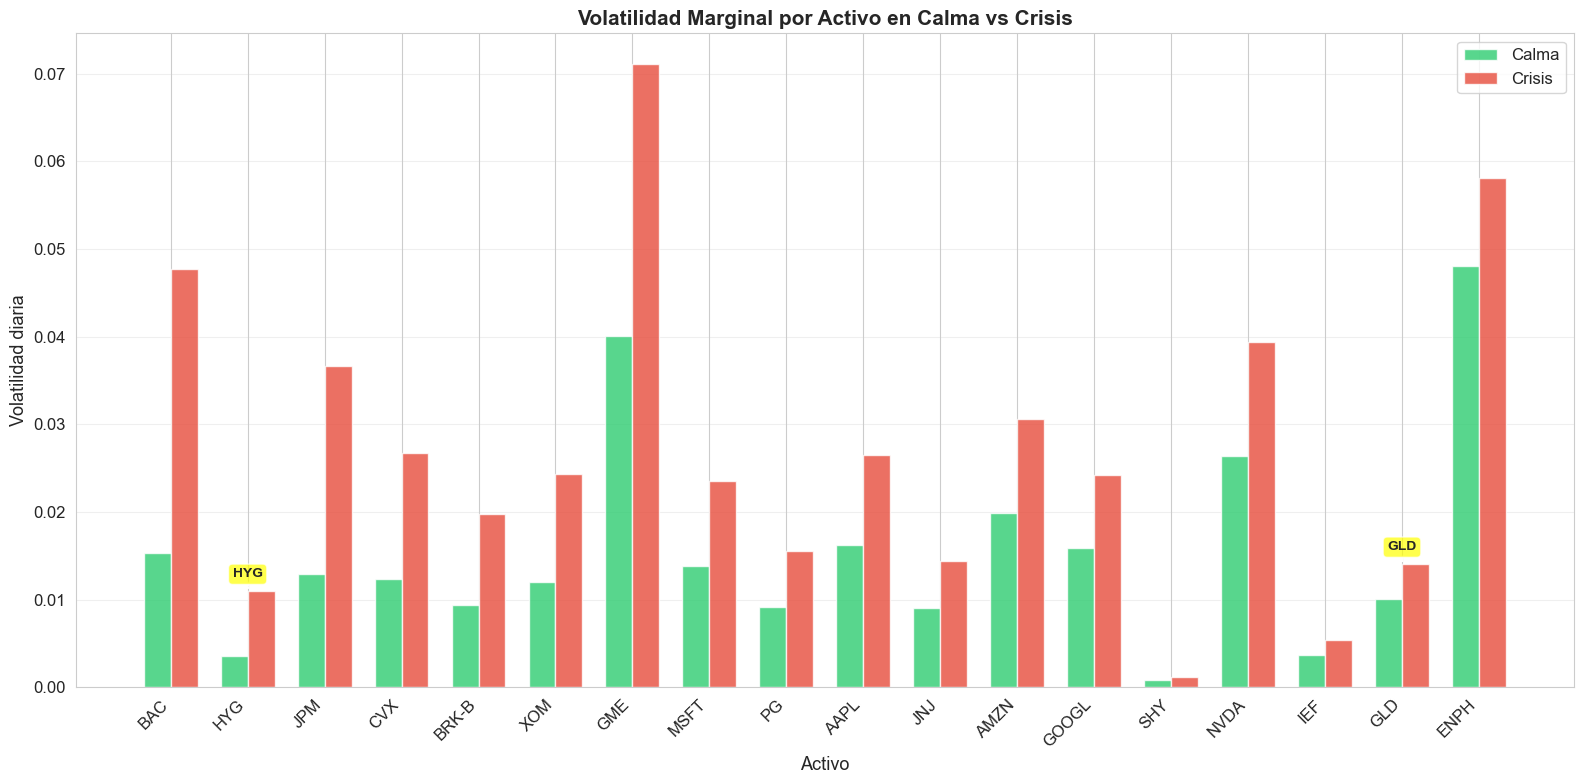

In [19]:
# ═══════════════════════════════════════════════════
# 4.4 Visualización: Cambio de volatilidad por activo
# ═══════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 8))

# Preparar datos
x = np.arange(len(changes_sorted))
width = 0.35

bars1 = ax.bar(x - width/2, changes_sorted['Vol_Calma'], width, 
               label='Calma', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, changes_sorted['Vol_Crisis'], width,
               label='Crisis', color='#e74c3c', alpha=0.8)

# Etiquetas y formato
ax.set_xlabel('Activo', fontsize=13)
ax.set_ylabel('Volatilidad diaria', fontsize=13)
ax.set_title('Volatilidad Marginal por Activo en Calma vs Crisis', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(changes_sorted['Activo'], rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Destacar HYG y GLD con anotaciones
for i, asset in enumerate(changes_sorted['Activo']):
    if asset in ['HYG', 'GLD']:
        ax.annotate(asset, xy=(i, changes_sorted.iloc[i]['Vol_Crisis']),
                   xytext=(0, 10), textcoords='offset points',
                   ha='center', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', lw=1.5))

plt.tight_layout()
plt.show()

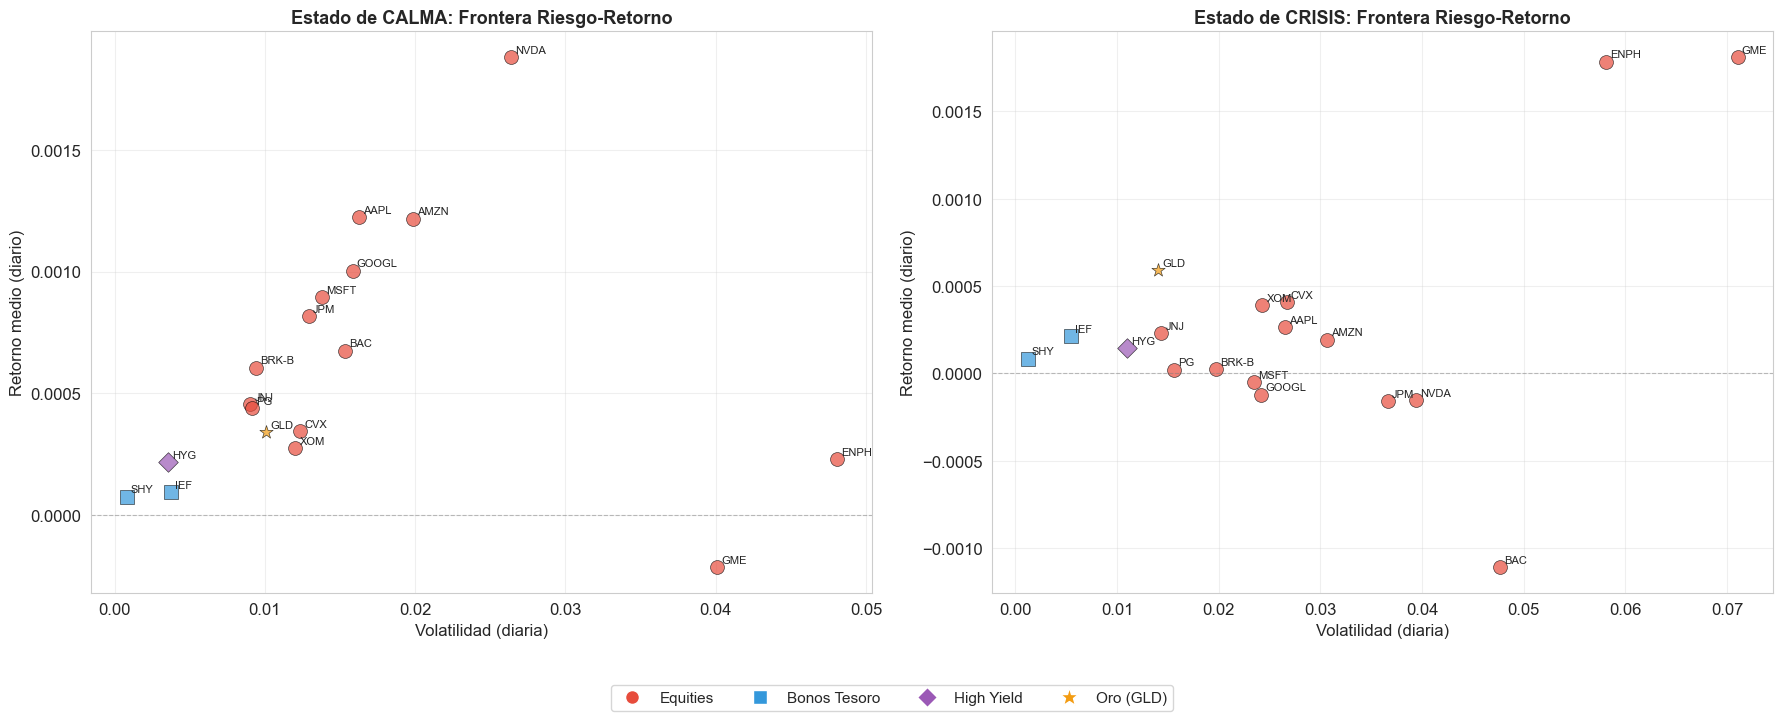

In [20]:
# ═══════════════════════════════════════════════════
# 4.5 Scatter plot: Media vs Volatilidad (frontera riesgo-retorno)
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Estado de Calma
ax1 = axes[0]
for asset in PORTFOLIO_TICKERS:
    if asset in marginal_pivot.index:
        # Después del swaplevel, el orden es ('Estado', 'Métrica')
        x = marginal_pivot.loc[asset, ('Calma', 'Volatilidad')]
        y = marginal_pivot.loc[asset, ('Calma', 'Media')]
        
        # Color según tipo de activo
        if asset in ['IEF', 'SHY']:
            color, marker = '#3498db', 's'  # Azul, cuadrado (bonos Tesoro)
        elif asset == 'HYG':
            color, marker = '#9b59b6', 'D'  # Púrpura, diamante (HY)
        elif asset == 'GLD':
            color, marker = '#f39c12', '*'  # Naranja, estrella (oro)
        else:
            color, marker = '#e74c3c', 'o'  # Rojo, círculo (equities)
        
        ax1.scatter(x, y, s=100, c=color, marker=marker, alpha=0.7, edgecolors='black', linewidth=0.5)
        ax1.annotate(asset, (x, y), fontsize=8, xytext=(3, 3), textcoords='offset points')

ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('Volatilidad (diaria)', fontsize=12)
ax1.set_ylabel('Retorno medio (diario)', fontsize=12)
ax1.set_title('Estado de CALMA: Frontera Riesgo-Retorno', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

# Estado de Crisis
ax2 = axes[1]
for asset in PORTFOLIO_TICKERS:
    if asset in marginal_pivot.index:
        x = marginal_pivot.loc[asset, ('Crisis', 'Volatilidad')]
        y = marginal_pivot.loc[asset, ('Crisis', 'Media')]
        
        if asset in ['IEF', 'SHY']:
            color, marker = '#3498db', 's'
        elif asset == 'HYG':
            color, marker = '#9b59b6', 'D'
        elif asset == 'GLD':
            color, marker = '#f39c12', '*'
        else:
            color, marker = '#e74c3c', 'o'
        
        ax2.scatter(x, y, s=100, c=color, marker=marker, alpha=0.7, edgecolors='black', linewidth=0.5)
        ax2.annotate(asset, (x, y), fontsize=8, xytext=(3, 3), textcoords='offset points')

ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Volatilidad (diaria)', fontsize=12)
ax2.set_ylabel('Retorno medio (diario)', fontsize=12)
ax2.set_title('Estado de CRISIS: Frontera Riesgo-Retorno', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

# Leyenda común
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Equities'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#3498db', markersize=10, label='Bonos Tesoro'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#9b59b6', markersize=10, label='High Yield'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#f39c12', markersize=14, label='Oro (GLD)')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02),
           ncol=4, fontsize=11, frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

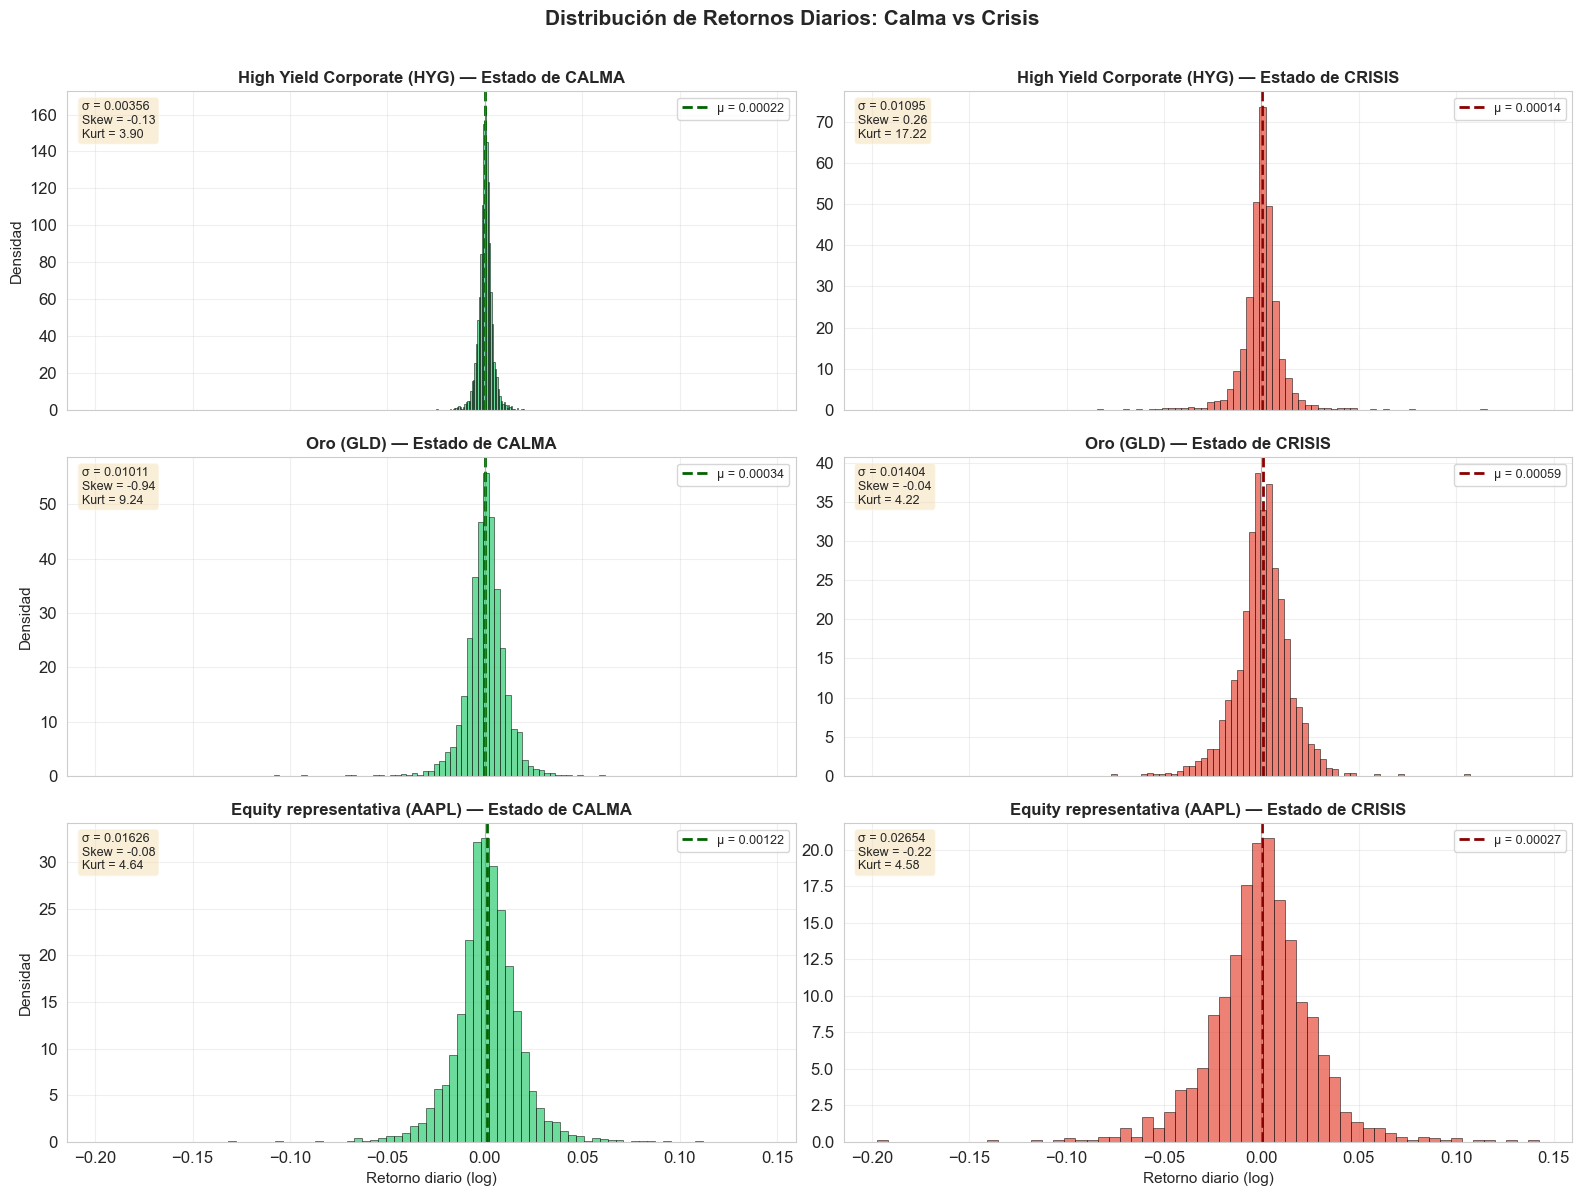

In [21]:
# ═══════════════════════════════════════════════════
# 4.6 Distribuciones de retornos: HYG, GLD y AAPL
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

# Activos clave a analizar
key_assets = [
    ('HYG', 'High Yield Corporate (HYG)'),
    ('GLD', 'Oro (GLD)'),
    ('AAPL', 'Equity representativa (AAPL)')
]

for row, (asset, title) in enumerate(key_assets):
    if asset not in portfolio_returns_aligned.columns:
        continue
    
    returns = portfolio_returns_aligned[asset].dropna()
    regimes_aligned = regimes.loc[returns.index]
    
    calm_returns = returns[regimes_aligned == 0]
    crisis_returns = returns[regimes_aligned == 1]
    
    # Histograma - Calma
    ax_calm = axes[row, 0]
    ax_calm.hist(calm_returns, bins=60, color='#2ecc71', alpha=0.7, density=True, edgecolor='black', linewidth=0.5)
    ax_calm.axvline(calm_returns.mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'μ = {calm_returns.mean():.5f}')
    ax_calm.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax_calm.set_ylabel('Densidad', fontsize=11)
    ax_calm.set_title(f'{title} — Estado de CALMA', fontsize=12, fontweight='bold')
    ax_calm.legend(fontsize=9)
    ax_calm.grid(alpha=0.3)
    
    # Añadir estadísticos
    text = f"σ = {calm_returns.std():.5f}\nSkew = {skew(calm_returns):.2f}\nKurt = {kurtosis(calm_returns):.2f}"
    ax_calm.text(0.02, 0.97, text, transform=ax_calm.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Histograma - Crisis
    ax_crisis = axes[row, 1]
    ax_crisis.hist(crisis_returns, bins=60, color='#e74c3c', alpha=0.7, density=True, edgecolor='black', linewidth=0.5)
    ax_crisis.axvline(crisis_returns.mean(), color='darkred', linestyle='--', linewidth=2, label=f'μ = {crisis_returns.mean():.5f}')
    ax_crisis.axvline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
    ax_crisis.set_title(f'{title} — Estado de CRISIS', fontsize=12, fontweight='bold')
    ax_crisis.legend(fontsize=9)
    ax_crisis.grid(alpha=0.3)
    
    text = f"σ = {crisis_returns.std():.5f}\nSkew = {skew(crisis_returns):.2f}\nKurt = {kurtosis(crisis_returns):.2f}"
    ax_crisis.text(0.02, 0.97, text, transform=ax_crisis.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1, 0].set_xlabel('Retorno diario (log)', fontsize=11)
axes[-1, 1].set_xlabel('Retorno diario (log)', fontsize=11)

fig.suptitle('Distribución de Retornos Diarios: Calma vs Crisis', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

Estadísticas de HYG


,Mean_HYG,Vol_HYG
Calma,0.054754,0.056447
Crisis,0.036286,0.173879


Estadísticas de GLD: 


,Mean_GLD,Vol_GLD
Calma,0.085877,0.160421
Crisis,0.149395,0.222928


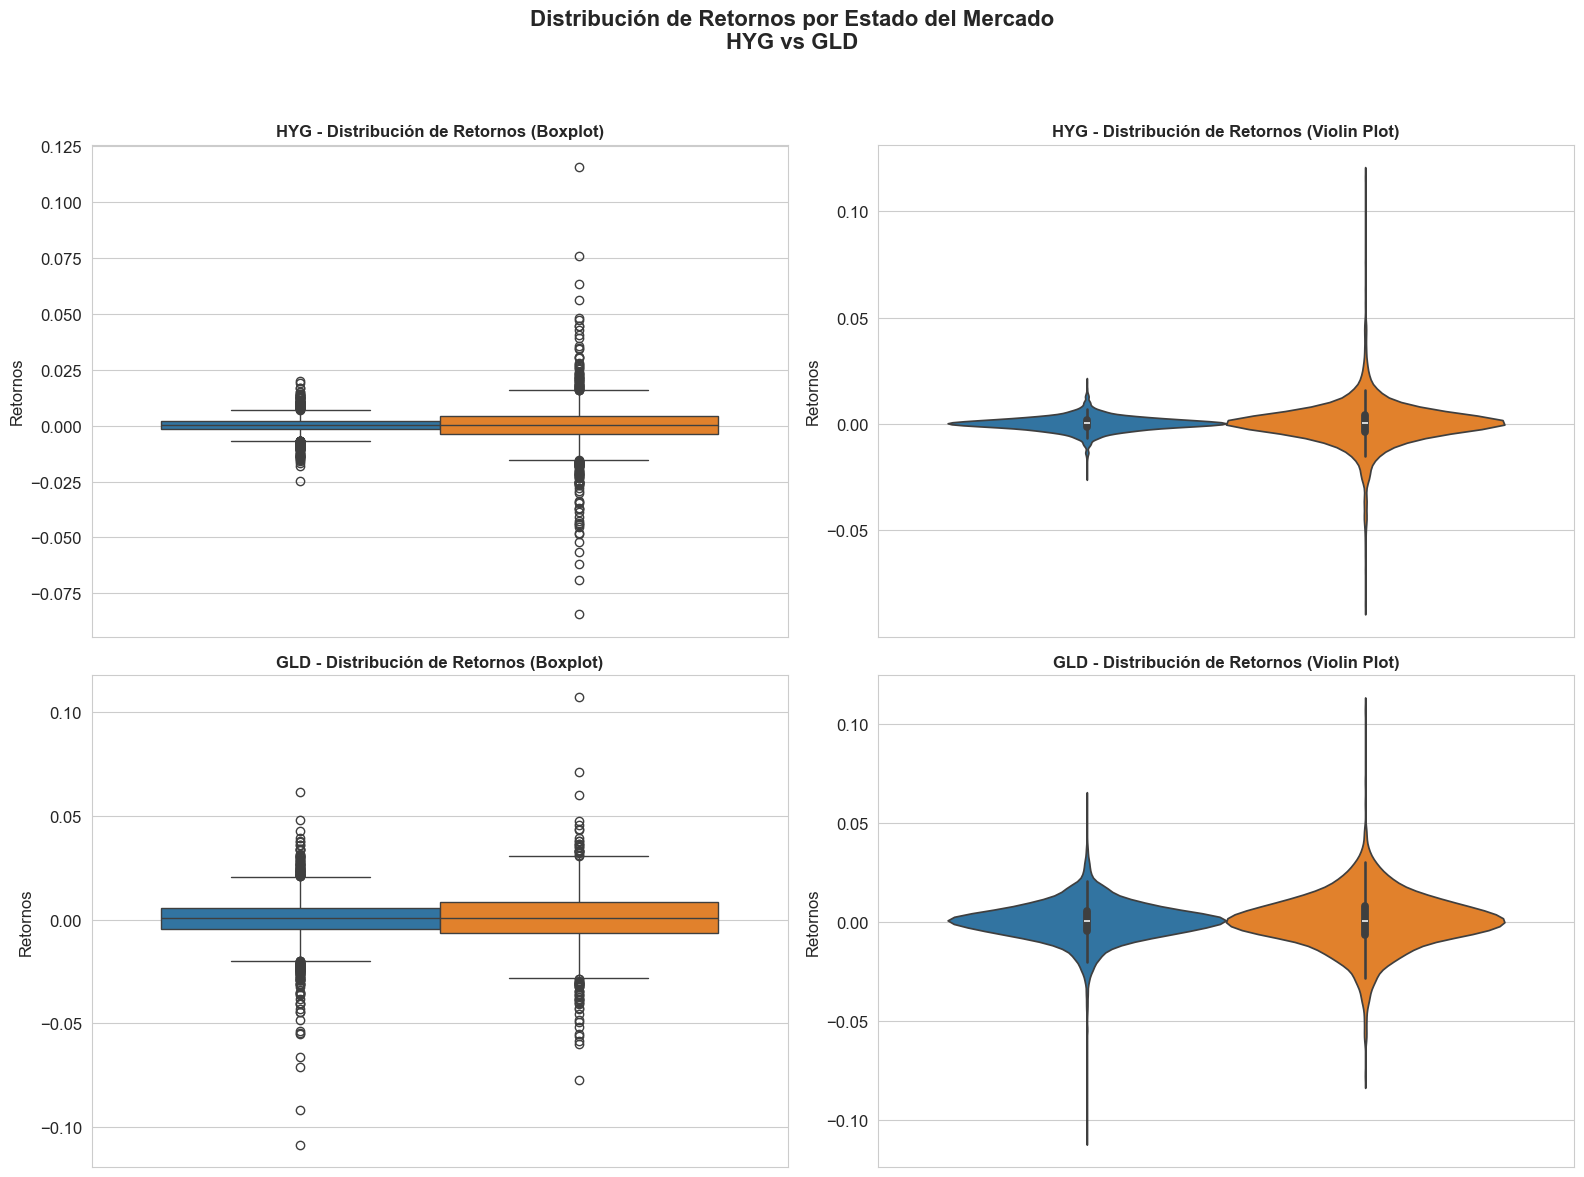

In [22]:
def dist_stats(df):
    #Filtramos por estado
    df_calma = df[df['Estado'] == 0]
    df_estres = df[df['Estado'] == 1]
    
    # Calculamos los indicadores para todas las variables (ESTADO CALMA) ANUALIZADO
    media_calma = df_calma.iloc[:,:-1].mean()*252
    vol_calma = df_calma.iloc[:,:-1].std()*np.sqrt(252)
    skewness_calma = df_calma.iloc[:,:-1].skew()
    kurtosis_calma = df_calma.iloc[:,:-1].kurt()
    
    # Calculamos los indicadores para todas las variables (ESTADO CRISIS) ANUALIZADO
    media_crisis = df_estres.iloc[:,:-1].mean()*252
    vol_crisis = df_estres.iloc[:,:-1].std()*np.sqrt(252)
    skewness_crisis = df_estres.iloc[:,:-1].skew()
    kurtosis_crisis = df_estres.iloc[:,:-1].kurt()
    
    df_calma_final = pd.DataFrame(data = {'Media': media_calma, 'Volatilidad': vol_calma, 
                                          'Skewness': skewness_calma, 'Kurtosis': kurtosis_calma})
    df_crisis_final = pd.DataFrame(data = {'Media': media_crisis, 'Volatilidad': vol_crisis, 
                                          'Skewness': skewness_crisis, 'Kurtosis': kurtosis_crisis})
    
    return df_calma_final, df_crisis_final

portfolio_returns_aligned['Estado'] = regimes
stats_calma, stats_crisis = dist_stats(portfolio_returns_aligned)

hyg_mean_calma, hyg_mean_crisis = stats_calma['Media'].loc['HYG'], stats_crisis['Media'].loc['HYG']
hyg_vol_calma, hyg_vol_crisis = stats_calma['Volatilidad'].loc['HYG'], stats_crisis['Volatilidad'].loc['HYG']
estado = ['Calma','Crisis']

HYG = pd.DataFrame(data = {'Mean_HYG': [hyg_mean_calma, hyg_mean_crisis],
                     'Vol_HYG': [hyg_vol_calma, hyg_vol_crisis]})
HYG.index = estado
print('Estadísticas de HYG')
display(HYG)

gld_mean_calma, gld_mean_crisis = stats_calma['Media'].loc['GLD'], stats_crisis['Media'].loc['GLD']
gld_vol_calma, gld_vol_crisis = stats_calma['Volatilidad'].loc['GLD'], stats_crisis['Volatilidad'].loc['GLD']
estado = ['Calma','Crisis']

GLD = pd.DataFrame(data = {'Mean_GLD': [gld_mean_calma, gld_mean_crisis],
                     'Vol_GLD': [gld_vol_calma, gld_vol_crisis]})
GLD.index = estado
print('Estadísticas de GLD: ')
display(GLD)

# ==================================================================
# GRÁFICO DE DISTRIBUCIONES DE HYG Y GLD (BOXPLOT Y VIOLINPLOT)
# ==================================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False)

# ======================
# HYG
# ======================

sns.boxplot(data=portfolio_returns_aligned, y='HYG', hue='Estado', ax=axes[0, 0])

axes[0, 0].set_title('HYG - Distribución de Retornos (Boxplot)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Retornos')
axes[0, 0].set_xlabel('')

sns.violinplot(data=portfolio_returns_aligned, y='HYG', hue='Estado', ax=axes[0, 1])

axes[0, 1].set_title('HYG - Distribución de Retornos (Violin Plot)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Retornos')
axes[0, 1].set_xlabel('')

# ======================
# GLD
# ======================
sns.boxplot(data=portfolio_returns_aligned, y='GLD', hue='Estado', ax=axes[1, 0])

axes[1, 0].set_title('GLD - Distribución de Retornos (Boxplot)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Retornos')
axes[1, 0].set_xlabel('')

sns.violinplot(data=portfolio_returns_aligned, y='GLD', hue='Estado', ax=axes[1, 1])

axes[1, 1].set_title('GLD - Distribución de Retornos (Violin Plot)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Retornos')
axes[1, 1].set_xlabel('')

# Eliminar leyendas duplicadas (dejamos solo una)
for ax in axes.flatten():
    ax.legend_.remove()

# Añadimos una sola leyenda global
handles, labels = axes[0,0].get_legend_handles_labels()

# Título general
fig.suptitle('Distribución de Retornos por Estado del Mercado\nHYG vs GLD', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2.2 Conclusiones de la Fase 2

**Hallazgos clave del análisis de riesgo marginal:**

1. **Volatilidad de HYG en crisis:**
   - La volatilidad de los bonos high yield (HYG) se multiplica significativamente en períodos de crisis, confirmando que el crédito corporativo se comporta como activo de riesgo cuando el mercado entra en estrés.
   - Esto es coherente con el fenómeno de "flight to quality" donde los inversores abandonan crédito de baja calidad hacia activos más seguros.

2. **GLD como activo refugio:**
   - El oro muestra características de protección en crisis:
     - Retornos que se mantienen o mejoran en estado de crisis
     - Incremento de volatilidad moderado comparado con equities
   - Sin embargo, no es un refugio perfecto: también sufre volatilidad durante períodos de estrés, aunque menor que activos de riesgo tradicionales.

3. **Asimetría y colas pesadas:**
   - Los activos de renta variable muestran **skewness negativo** más pronunciado en crisis (colas largas a la izquierda = pérdidas extremas)
   - El **exceso de curtosis** aumenta en crisis para todos los activos, indicando mayor probabilidad de eventos extremos
   - Los bonos del Tesoro (IEF, SHY) mantienen distribuciones más estables entre regímenes

4. **Implicaciones para la gestión de riesgos:**
   - Los modelos que asumen distribuciones normales y parámetros constantes **subestiman el riesgo** en crisis
   - La diversificación tradicional (mix de equities y bonos corporativos) **pierde efectividad** cuando aumentan las correlaciones
   - Los únicos activos con comportamiento genuinamente diferenciado en crisis son los bonos del Tesoro y, en menor medida, el oro

# **Fase 3: Cuando la Diversificación Falla (Cópulas)**

**Objetivo**: Probar que, en crisis, las correlaciones tienden a 1.

- Tarea Técnica:
    - Calcular matriz de correlación de Pearson en Estado "Calma".
    - Calcular matriz de correlación en Estado "Estrés".
    - Ajustar las cópulas en ambos estados.

Antes de pasar a la siguiente fase, contesta a la pregunta: Al comparar los dos regímenes identificados por el modelo, ¿qué características del mercado dirías que realmente distinguen un estado del otro? Sustenta tu respuesta con evidencia cuantitativa (tablas/gráficos) y una interpretación económica

## 3.2. CÁLCULO DE MATRICES DE CORRELACIÓN

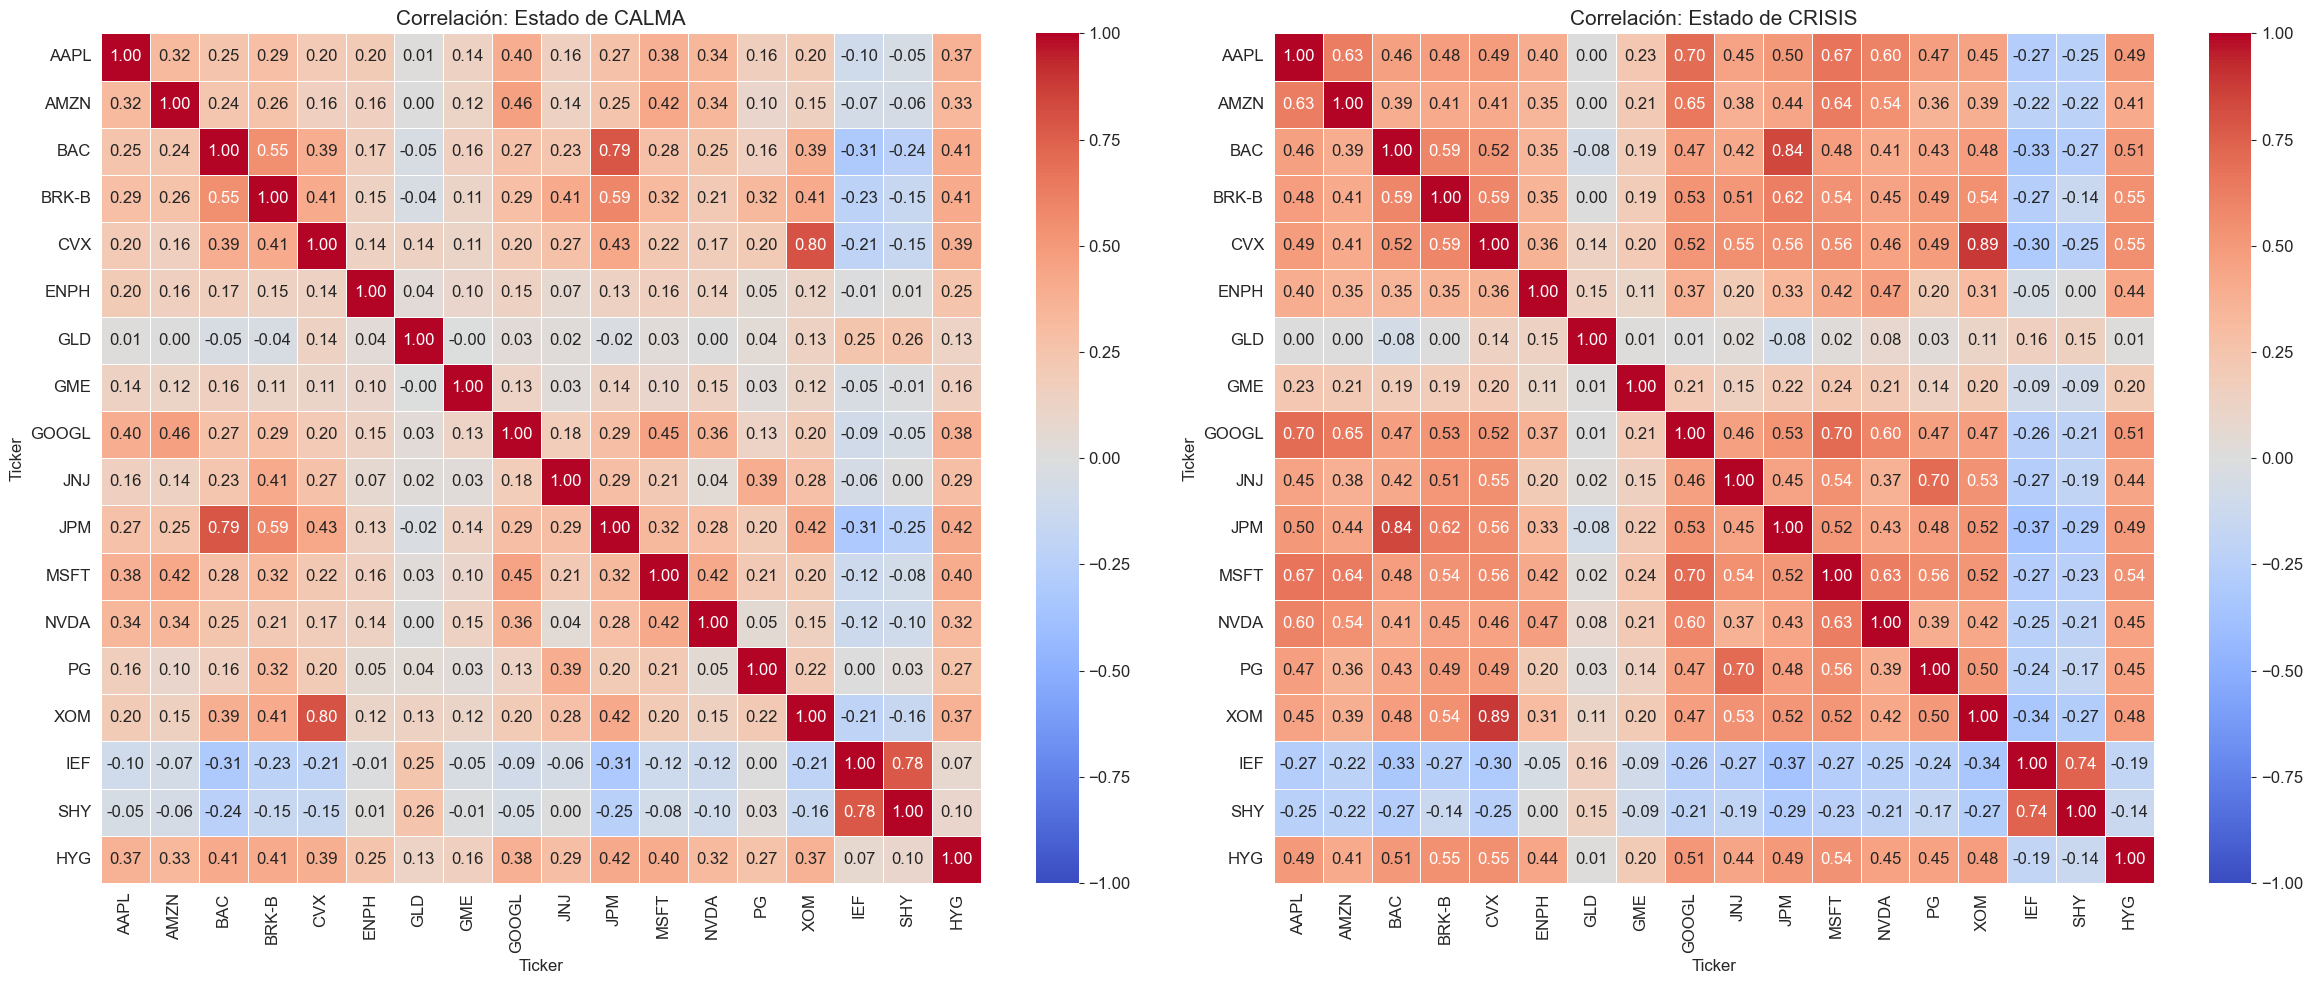

In [23]:
# Calculamos la matriz de correlaciones para las observaciones en estado de calma
df_calma = portfolio_returns_aligned[portfolio_returns_aligned['Estado'] == 0].iloc[:,:-1]
corr_calma = df_calma.corr(method='pearson')

# Calculamos la matriz de correlaciones para las observaciones en estado de crisis
df_crisis = portfolio_returns_aligned[portfolio_returns_aligned['Estado'] == 1].iloc[:,:-1]
corr_crisis = df_crisis.corr(method='pearson')

# ====================================
# MATRICES DE CORRELACIONES DE RETORNOS (CALMA VS CRISIS)
# ====================================
# 1. Creamos una figura con 1 fila y 2 columnas
# Ajustamos el tamaño para que quepan bien ambos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# 2. Mapa de calor para CALMA (en el primer eje: ax1)
sns.heatmap(
    corr_calma,
    linewidths=0.5,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    ax=ax1  # <--- IMPORTANTE: indicamos el eje
)
ax1.set_title("Correlación: Estado de CALMA", fontsize=15)

# 3. Mapa de calor para CRISIS (en el segundo eje: ax2)
sns.heatmap(
    corr_crisis,
    linewidths=0.5,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    ax=ax2  # <--- IMPORTANTE: indicamos el eje
)
ax2.set_title("Correlación: Estado de CRISIS", fontsize=15)

# Ajuste automático para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

Viendo la comparativa de las matrices de correlaciones de los retornos de los activos, tanto en el estado de calma como en el de crisis, podemos apreciar que **las correlaciones en estado de crisis se intensifican de forma generalizada**. Destaca la mayor intensidad de colores del heatmap de las correlaciones de los retornos en estado de crisis. Es decir, tal y como se esperaba, **la diversificación no es tan efectiva en épocas de crisis**.

### MATRICES DE CORRELACIONES DE CADA UNA DE LAS CALMAS

In [24]:
# Supongamos que tus fechas están en un DataFrame llamado 'fechas_crisis'
# con columnas 'Inicio' y 'Fin' (asegúrate de que sean tipo datetime)
fechas_crisis = regimes_df[regimes_df['Estado'] == 0]

# 1. Creamos una lista para almacenar los fragmentos de datos de crisis
# Diccionario para guardar las matrices: { "Fecha_Inicio": matriz_corr }
matrices_por_periodo = {}
crisis = 0
# 1. Iteramos sobre cada crisis individualmente
for i, fila in fechas_crisis.iterrows():
    inicio, fin = fila['Inicio'], fila['Fin']
    
    # Filtramos los datos para este periodo específico
    datos_periodo = portfolio_returns_aligned.loc[inicio:fin].iloc[:,:-1]

    # Verificamos que haya suficientes datos para calcular correlación
    if len(datos_periodo) > 5:
        crisis +=1
        # Calculamos la matriz y la guardamos con una etiqueta clara
        nombre_periodo = f"Crisis_{inicio}-{fin}"
        matrices_por_periodo[nombre_periodo] = datos_periodo.corr()
        
        print(f"Matriz generada para: {nombre_periodo} ({len(datos_periodo)} días)")
    else:
        print(f"Periodo {inicio} a {fin} demasiado corto, saltando...")

Matriz generada para: Crisis_2006-01-18-2007-07-26 (383 días)
Matriz generada para: Crisis_2007-09-19-2007-10-31 (31 días)
Matriz generada para: Crisis_2010-01-12-2010-05-03 (77 días)
Matriz generada para: Crisis_2010-10-11-2011-07-28 (202 días)
Matriz generada para: Crisis_2012-02-02-2012-05-10 (69 días)
Matriz generada para: Crisis_2012-07-02-2015-08-20 (789 días)
Matriz generada para: Crisis_2015-10-20-2015-12-08 (35 días)
Matriz generada para: Crisis_2016-04-15-2018-11-20 (657 días)
Matriz generada para: Crisis_2018-12-10-2020-02-21 (302 días)
Matriz generada para: Crisis_2021-03-22-2022-01-04 (201 días)
Matriz generada para: Crisis_2022-11-28-2025-03-19 (578 días)
Matriz generada para: Crisis_2025-05-28-2026-02-06 (176 días)


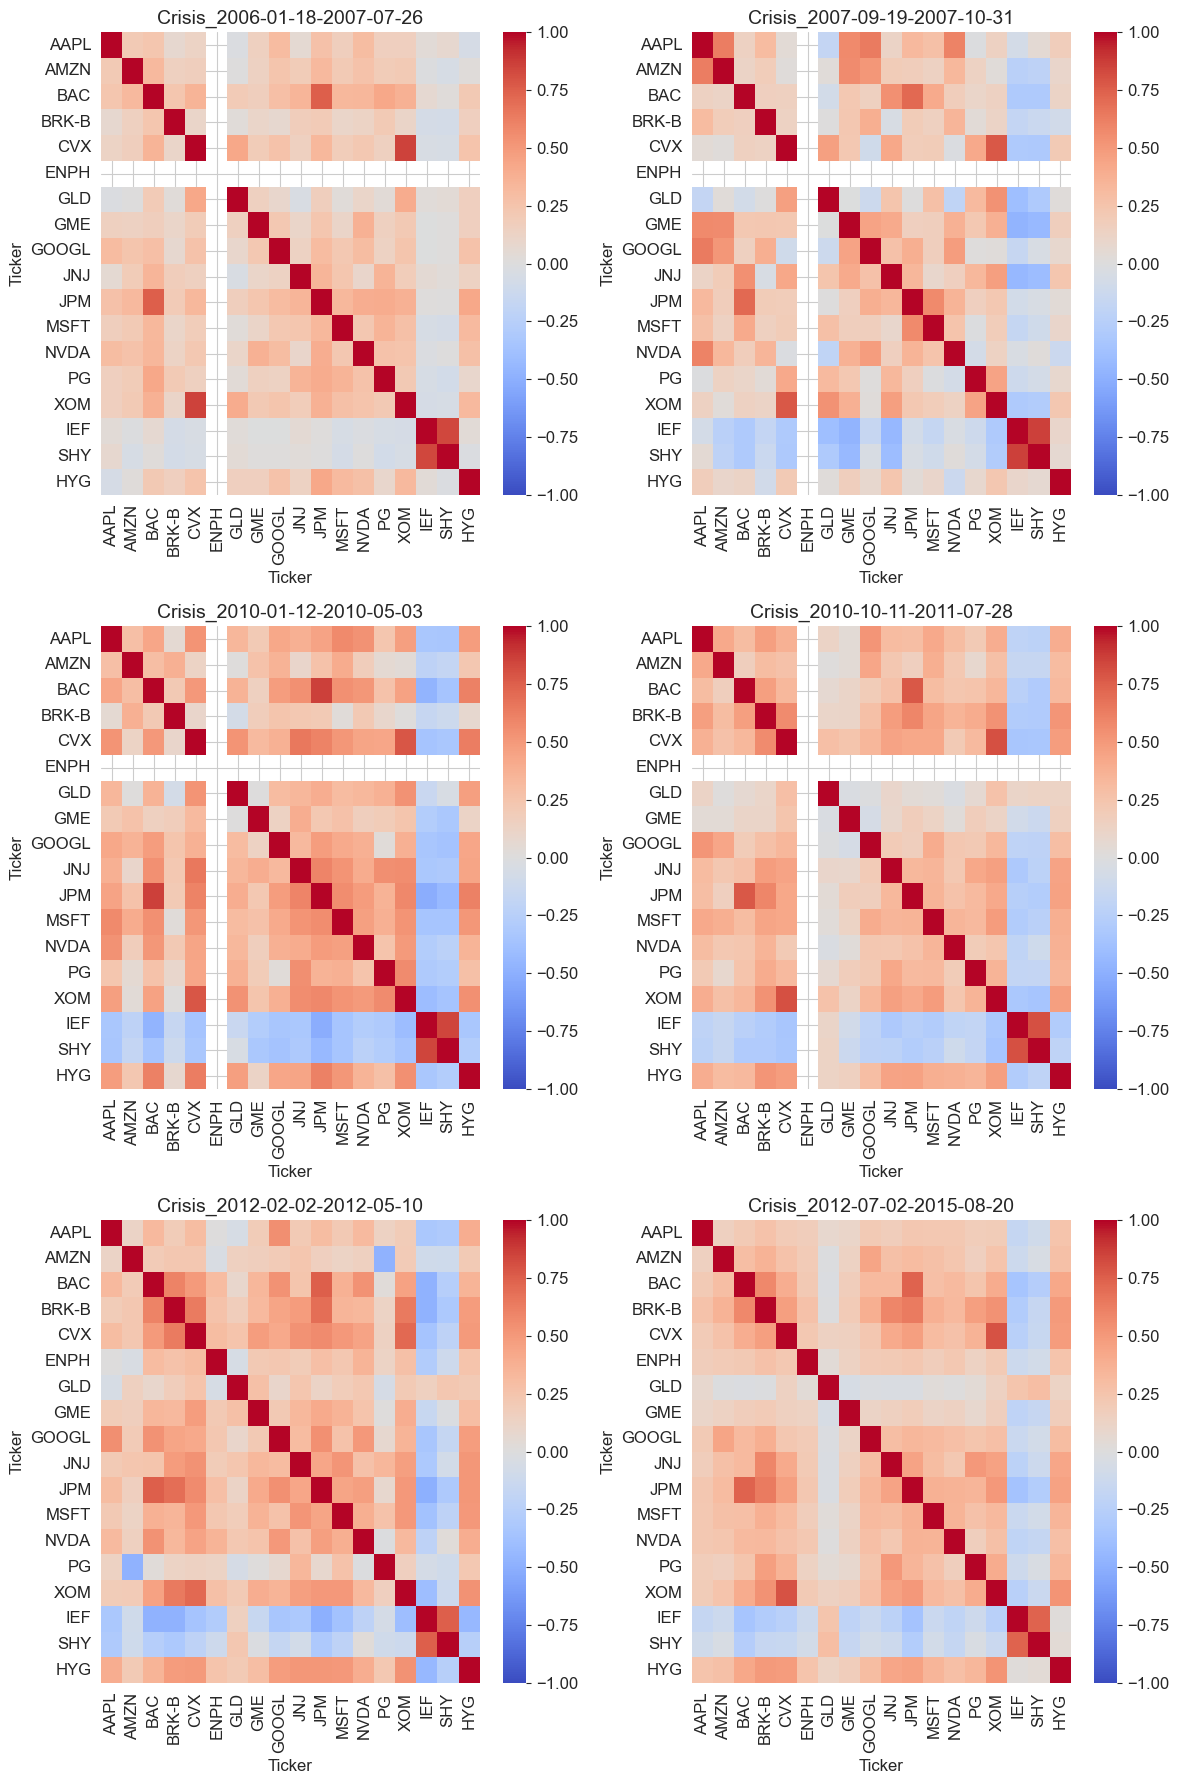

In [25]:
# Definimos la estructura 3x2
filas = 3
columnas = 2
fig, axes = plt.subplots(filas, columnas, figsize=(12, 18)) # Ajustamos el alto para 3 filas

# Aplanamos los ejes para que sea fácil recorrerlos con un solo bucle
axes_flat = axes.flatten()

# Iteramos sobre las matrices y los ejes aplanados
for i, (nombre, matriz) in enumerate(matrices_por_periodo.items()):
    if i < len(axes_flat): # Evitamos error si hay más de 6 matrices
        ax = axes_flat[i]
        sns.heatmap(matriz, 
                    ax=ax, 
                    cmap="coolwarm", 
                    vmin=-1, vmax=1, 
                    annot=False, 
                    cbar=True) # Cbar en cada una para mejor lectura individual
        ax.set_title(nombre, fontsize=14)
    
# Si sobran huecos en la cuadrícula (por ejemplo si tienes solo 5 crisis), 
# ocultamos los ejes vacíos
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

### MATRICES DE CORRELACIONES DE CADA UNA DE LAS CRISIS

In [26]:
# Supongamos que tus fechas están en un DataFrame llamado 'fechas_crisis'
# con columnas 'Inicio' y 'Fin' (asegúrate de que sean tipo datetime)
fechas_crisis = regimes_df[regimes_df['Estado'] == 1]

# 1. Creamos una lista para almacenar los fragmentos de datos de crisis
# Diccionario para guardar las matrices: { "Fecha_Inicio": matriz_corr }
matrices_por_periodo = {}
crisis = 0
# 1. Iteramos sobre cada crisis individualmente
for i, fila in fechas_crisis.iterrows():
    inicio, fin = fila['Inicio'], fila['Fin']
    
    # Filtramos los datos para este periodo específico
    datos_periodo = portfolio_returns_aligned.loc[inicio:fin].iloc[:,:-1]

    # Verificamos que haya suficientes datos para calcular correlación
    if len(datos_periodo) > 5:
        crisis +=1
        # Calculamos la matriz y la guardamos con una etiqueta clara
        nombre_periodo = f"Crisis_{inicio}-{fin}"
        matrices_por_periodo[nombre_periodo] = datos_periodo.corr()
        
        print(f"Matriz generada para: {nombre_periodo} ({len(datos_periodo)} días)")
    else:
        print(f"Periodo {inicio} a {fin} demasiado corto, saltando...")

Matriz generada para: Crisis_2007-07-27-2007-09-18 (37 días)
Matriz generada para: Crisis_2007-11-01-2010-01-11 (552 días)
Matriz generada para: Crisis_2010-05-04-2010-10-08 (111 días)
Matriz generada para: Crisis_2011-07-29-2012-02-01 (129 días)
Matriz generada para: Crisis_2012-05-11-2012-06-29 (35 días)
Matriz generada para: Crisis_2015-08-21-2015-10-19 (41 días)
Matriz generada para: Crisis_2015-12-09-2016-04-14 (87 días)
Matriz generada para: Crisis_2020-02-24-2021-03-19 (271 días)
Matriz generada para: Crisis_2022-01-05-2022-11-25 (225 días)
Matriz generada para: Crisis_2025-03-20-2025-05-27 (47 días)


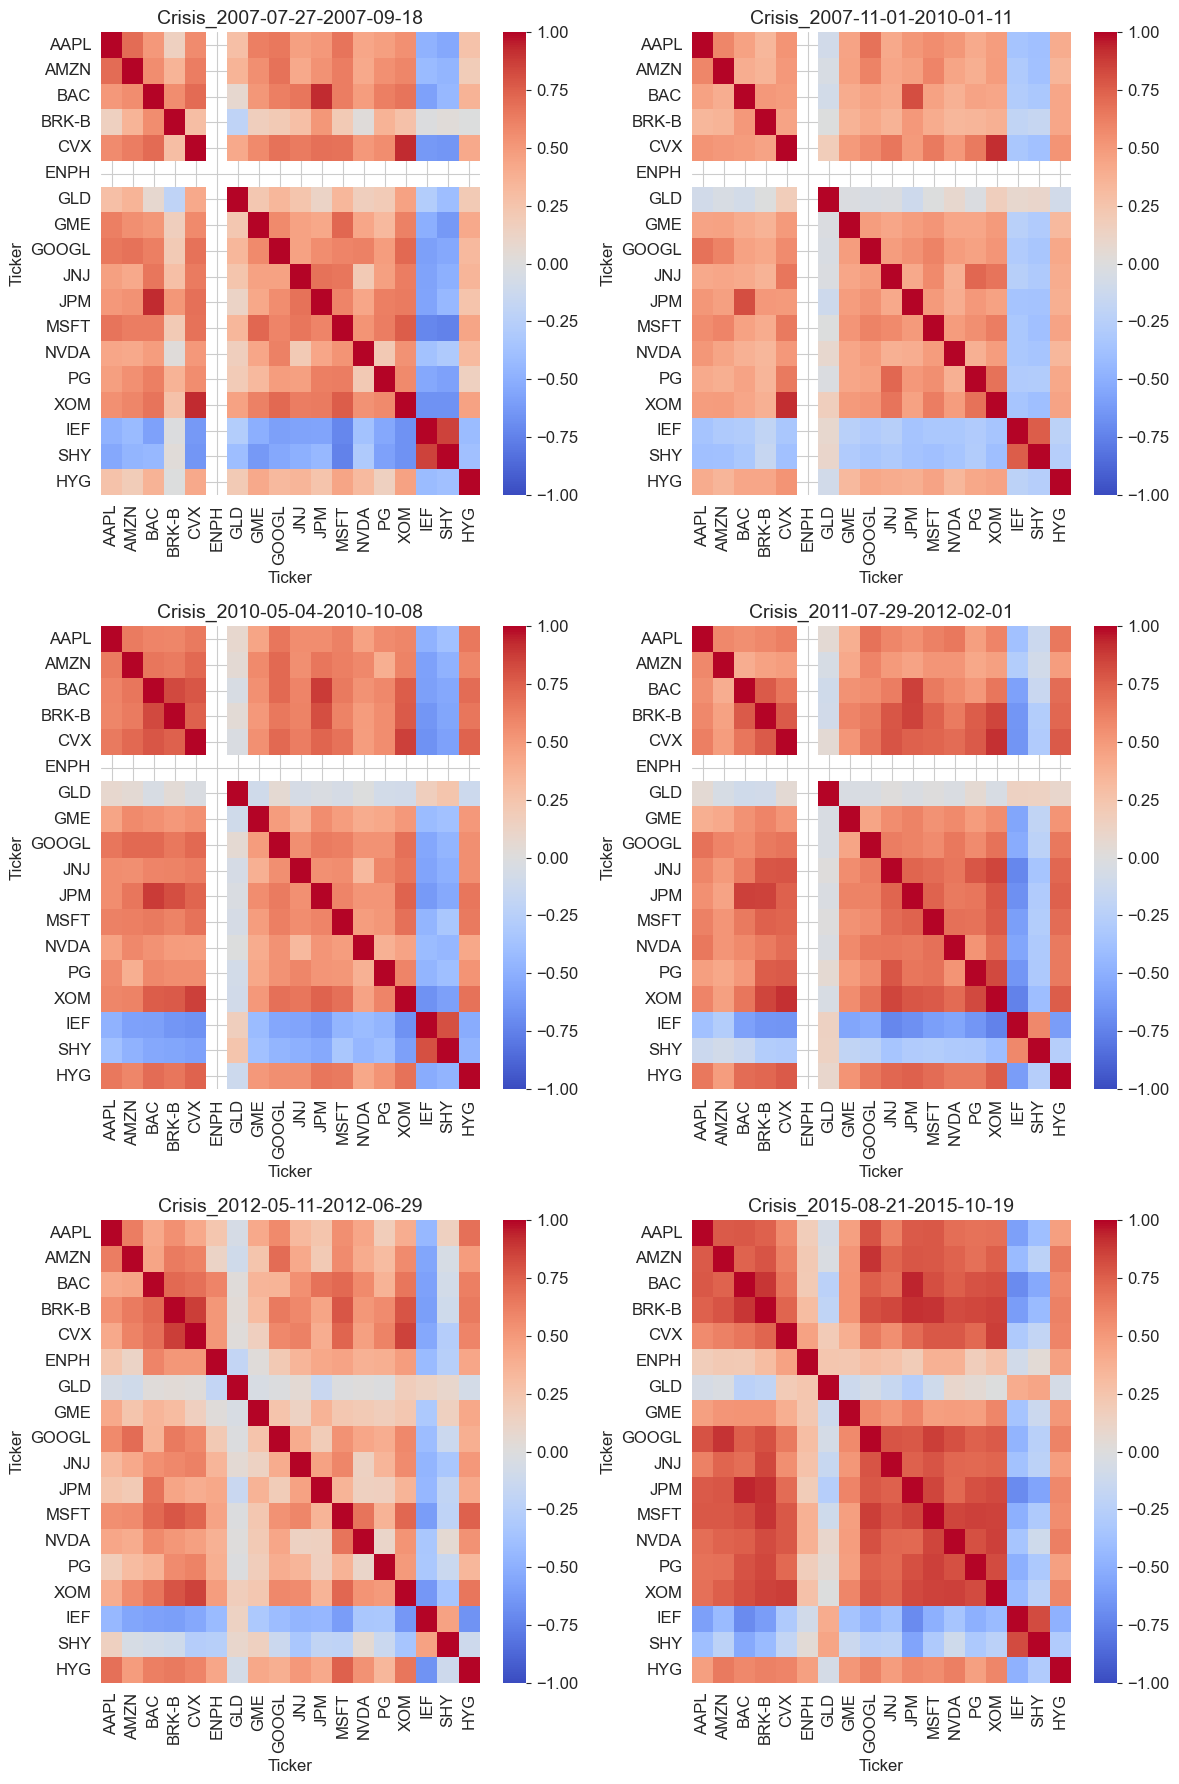

In [27]:
# Definimos la estructura 3x2
filas = 3
columnas = 2
fig, axes = plt.subplots(filas, columnas, figsize=(12, 18)) # Ajustamos el alto para 3 filas

# Aplanamos los ejes para que sea fácil recorrerlos con un solo bucle
axes_flat = axes.flatten()

# Iteramos sobre las matrices y los ejes aplanados
for i, (nombre, matriz) in enumerate(matrices_por_periodo.items()):
    if i < len(axes_flat): # Evitamos error si hay más de 6 matrices
        ax = axes_flat[i]
        sns.heatmap(matriz, 
                    ax=ax, 
                    cmap="coolwarm", 
                    vmin=-1, vmax=1, 
                    annot=False, 
                    cbar=True) # Cbar en cada una para mejor lectura individual
        ax.set_title(nombre, fontsize=14)
    
# Si sobran huecos en la cuadrícula (por ejemplo si tienes solo 5 crisis), 
# ocultamos los ejes vacíos
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

## 3.2. CÁLCULO DE LA CÓPULA ENTRE ESTADOS DE CALMA Y CRISIS

A la hora de construir la cópula, no podemos tener datos nulos. En este caso, apreciamos que los activos **ENPH y HYG presentan valores nulos**. Por lo tanto, se ha decidido no tenerlos en cuenta para el resto del ejercicio. El resto de activos tienen datos completos desde 2006 hasta la actualidad.

In [28]:
# Generamos el dataset con los activos sin valores nulos. Incluimos también el vector de estados.
lista_sin_nulos = ['AAPL', 'AMZN', 'BAC', 'BRK-B', 'CVX', 'GLD', 'GME', 'GOOGL',
                   'JNJ','JPM', 'MSFT', 'NVDA', 'PG', 'XOM', 'IEF', 'SHY', 'Estado']
df_cartera = portfolio_returns_aligned[lista_sin_nulos]

In [29]:
# 1. Preparar datos (deben estar transformados a marginales uniformes [0,1])
def get_pseudo_obs(data):
    return data.rank() / (len(data) + 1)

# 2. Ajuste de Cópula t-Student (la mejor para detectar dependencia en crisis)
# Estado Calma
u_calma = get_pseudo_obs(df_cartera[df_cartera['Estado'] == 0].iloc[:,:-1])
#cop_calma = StudentCopula(dim=u_calma.shape[1])
#cop_calma.fit(u_calma)
#print('Calma hecho...')

# Estado Crisis
u_crisis = get_pseudo_obs(df_cartera[df_cartera['Estado'] == 1].iloc[:,:-1])
#cop_crisis = StudentCopula(dim=u_crisis.shape[1])
#cop_crisis.fit(u_crisis)

In [30]:
# Para cargarlos en el futuro:
with open('modelos_copulas_60.pkl', 'rb') as f:
    data = pickle.load(f)
    cop_calma = data['calma']
    cop_crisis = data['crisis']

In [31]:
# Copia de modelo backup
u_calma_backup = u_calma
cop_calma_backup = cop_calma

u_crisis_backup = u_crisis
cop_crisis_backup = cop_crisis

Como conclusión, la cópula con los datos de estados de calma tiene más grados de libertad que los de estado de crisis. Por lo tanto, esto es indicativo de que las colas de los retornos en periodos de crisis son mucho más pesadas.

### GUARDAMOS LOS PARÁMETROS DEL MODELO PARA ESTADOS DE CALMA Y CRISIS DEBIDO A SU COSTE TEMPORAL

In [32]:
# Guardar los modelos entrenados
#with open('modelos_copulas_60.pkl', 'wb') as f:
    #pickle.dump({'calma': cop_calma, 'crisis': cop_crisis}, f)

In [33]:
cop_calma.params

StudentParams(df=np.float64(15.192485859498328), rho=array([ 0.40467396,  0.27999447,  0.31683361,  0.23096485,  0.00959687,
        0.20004825,  0.45424446,  0.18223481,  0.30197158,  0.43805612,
        0.383814  ,  0.18285397,  0.22305307, -0.10847175, -0.06663216,
        0.29402098,  0.3232457 ,  0.20594217, -0.00432505,  0.21597126,
        0.56833313,  0.19244046,  0.32087467,  0.51357765,  0.43204603,
        0.16023008,  0.19956282, -0.09889377, -0.07057759,  0.58163255,
        0.40349661, -0.0743374 ,  0.24331972,  0.31693333,  0.24901275,
        0.79895912,  0.32074122,  0.29197639,  0.18068113,  0.39885019,
       -0.33371577, -0.25361273,  0.42436888, -0.04969925,  0.2019072 ,
        0.34374471,  0.43315779,  0.61894934,  0.37189268,  0.25307373,
        0.35844952,  0.43078769, -0.24096172, -0.17158535,  0.1404633 ,
        0.18431127,  0.24481459,  0.27786443,  0.44131301,  0.26437007,
        0.20933239,  0.21981994,  0.81068043, -0.2158168 , -0.15394963,
       -0.0

In [34]:
cop_crisis.params

StudentParams(df=np.float64(7.32213406251567), rho=array([ 0.67283691,  0.49470463,  0.50556088,  0.46950964,  0.05735275,
        0.36189139,  0.71685228,  0.43481151,  0.51670089,  0.70334184,
        0.62650596,  0.46960874,  0.43951466, -0.27447798, -0.22624627,
        0.46708632,  0.4709155 ,  0.42567448,  0.03011239,  0.35671802,
        0.72251979,  0.4027737 ,  0.49045893,  0.68765247,  0.61186952,
        0.40378335,  0.39113751, -0.25631136, -0.21519994,  0.6690405 ,
        0.58196326, -0.03338444,  0.35713574,  0.53157544,  0.45461522,
        0.88296035,  0.52363085,  0.47030073,  0.47509347,  0.54853763,
       -0.40210906, -0.29607637,  0.59308873,  0.0169553 ,  0.33227746,
        0.55736305,  0.53316436,  0.67052341,  0.54317068,  0.46425574,
        0.51924812,  0.56085342, -0.32417793, -0.17370864,  0.14114911,
        0.32519752,  0.50359624,  0.49100921,  0.5908967 ,  0.51362362,
        0.44293067,  0.47271779,  0.89030965, -0.3565509 , -0.2483557 ,
        0.032

# **Fase 4: El Motor de Simulación**

**Objetivo**: Crear el futuro sintético (y validarlo). Implementa una simulación de Monte Carlo (10.000 trayectorias) y una duración de 6 meses que genere retornos multiactivo coherentes con los regímenes estimados y con la estructura de dependencia en colas.

**Tarea técnica (simulador)**: Tu simulador debe, para cada trayectoria y para cada día:
1. **Simular el estado $𝑺_𝒕$** usando la cadena de Markov estimada (matriz de transición del HMM).
2. **Simular los retornos $𝑹_𝒕$** de todos los activos condicionados al estado activo $𝑺_𝒕$, usando:
    - las marginales/volatilidades estimadas para ese estado, y
    - la cópula calibrada para ese estado (en particular, la de “estrés” debe capturar la dependencia en colas).

**Validación obligatoria (cartera + checks)**: Para comprobar que el simulador “se parece al mundo real”, realiza las siguientes validaciones:

**1) Test de cartera (sanity check)**:
- Construye una **cartera equiponderada** con los activos del universo (pesos iguales).
- Calcula la evolución histórica real de la cartera (wealth index).
- Simula 10.000 trayectorias de retornos y construye 10.000 trayectorias de la rentabilidad para la misma cartera.
- Compara la serie real con el “abanico” simulado:
    - gráfico con la trayectoria real y las bandas **p5–p50–p95** del wealth simulado,
    - distribución de retornos diarios simulados vs reales (histograma o percentiles).

**2) Reproducción de regímenes**:
- Reporta y compara (real vs simulado):
    - % de días en cada estado,
    - duración media de cada estado,
    - número de cambios de estado.

**3) Reproducción de riesgo y dependencia (lo importante)**:
- Para la cartera equiponderada, compara (real vs simulado):
    - **volatilidad** (diaria/anualizada),
    - **máximo drawdown**,
    - **VaR 99% y Expected Shortfall (CVaR 99%)**
- Verifica que en el estado de estrés el simulador reproduce:
    - aumento de volatilidades,
    - cambios en correlaciones (y/o co-movimientos extremos) coherentes con crisis.

## 4.1.1. Simula el estado $S_t$

Obtenemos tantos vectores de pesos como simulaciones. Cada uno de los vectores de pesos tendrá tantas posiciones como número de días a simular. 

In [35]:
# Función que genera para cada simulación un vector de estados
# ¡¡¡IMPORTANTE!!! -> EL NÚMERO DE DÍAS SE PONE EN EL PARÁMETRO DÍAS

def simular_estados(matriz_transicion, dias, p):
    
    # Generamos un vector de estados. Tantas posiciones como días a simular
    estados_simulados = np.zeros((dias), dtype=int)
    estados_simulados[0] = np.random.choice([0, 1], p=[p, 1-p])
    
    for i in range(1, dias):
        estado_actual = estados_simulados[i-1]
        # Probabilidades de transición desde el estado actual
        p = matriz_transicion[estado_actual] 
        # Elegimos el siguiente estado basándonos en P
        estados_simulados[i] = np.random.choice([0, 1], p=p)
            
    #estados_simulados = median_filter(estados_simulados, size=10)
    return estados_simulados

In [36]:
# Usamos como p la probabilidad muestral de que el periodo sea de calma para generar los estados iniciales
p = df_cartera[df_cartera['Estado'] == 0].shape[0]/df_cartera.shape[0]
#p_trans = best_model.transmat_.copy()
estados_sim = simular_estados(transmat, 126, p)
estados_sim

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## 4.1.2. Simular los retornos $R_t$

Generamos las simulaciones de retornos para cada activo usando la cópula y los marginales de cada activo en función del estado del mercado.

In [37]:
def simular_retornos(estados, cop_calma, cop_crisis, params_calma, params_crisis):
    
    n_dias = len(estados)
    n_activos = 16
    retornos_finales = np.zeros((n_dias, n_activos))
    
    # Separamos qué simulaciones están en cada estado hoy
    idx_calma = np.where(estados == 0)[0]
    idx_crisis = np.where(estados == 1)[0]
    
    # Simulación para los que están en Calma
    if len(idx_calma) > 0:
        # Cálculo mediante cópulas
        if len(idx_calma) == 1:
            u_calma = cop_calma.random([len(idx_calma)]).values
        else:
            u_calma = cop_calma.random(len(idx_calma)).values
        for i in range(n_activos):
            # Obtenemos los percentiles de cada retorno simulado en épocas de calma teniendo en cuenta la 
            # distribución de cada activo
            retornos_finales[idx_calma, i] = t.ppf(u_calma[:, i], df=cop_calma.params.df, 
                                                   loc=params_calma['mu'][i], 
                                                   scale=params_calma['sigma'][i])
            
    # Simulación para los que están en Crisis
    if len(idx_crisis) > 0:
        # Cálculo mediante cópulas
        if len(idx_crisis) == 1:
            u_crisis = cop_crisis.random([len(idx_crisis)]).values
        else:
            u_crisis = cop_crisis.random(len(idx_crisis)).values
        for i in range(n_activos):
            # Obtenemos los percentiles de cada retorno simulado en épocas de calma teniendo en cuenta la 
            # distribución de cada activo
            retornos_finales[idx_crisis, i] = t.ppf(u_crisis[:, i], df=cop_crisis.params.df, 
                                                    loc=params_crisis['mu'][i], 
                                                    scale=params_crisis['sigma'][i])
    
    return retornos_finales

In [38]:
params_calma = {'mu': df_cartera[df_cartera['Estado'] == 0].iloc[:,:-1].mean().values,
                'sigma': df_cartera[df_cartera['Estado'] == 0].iloc[:,:-1].std().values}

params_crisis = {'mu': df_cartera[df_cartera['Estado'] == 1].iloc[:,:-1].mean().values,
                 'sigma': df_cartera[df_cartera['Estado'] == 1].iloc[:,:-1].std().values}

# Esto genera los retornos de 1 simulación (126 días)
lol = np.ones(126)
lol[0] = 1
retornos_sim = simular_retornos(lol, cop_calma, cop_crisis, params_calma, params_crisis)
retornos_sim

array([[-0.02328265, -0.03669285, -0.04673667, ..., -0.00028867,
         0.00384416,  0.0019594 ],
       [-0.00213366,  0.00136999, -0.03840648, ...,  0.00639624,
         0.00517945,  0.00059044],
       [ 0.05621046,  0.08559711, -0.00464171, ...,  0.009864  ,
        -0.00417138, -0.00087082],
       ...,
       [-0.00590494,  0.03813032,  0.0739889 , ...,  0.05476788,
        -0.0085071 , -0.00094312],
       [-0.02917471,  0.02328447, -0.03281919, ..., -0.00978521,
         0.00534273,  0.00093143],
       [-0.03276127, -0.02401144,  0.01053362, ..., -0.00750582,
         0.003956  ,  0.00076967]], shape=(126, 16))

## 4.1.3. Generación de la simulación de Monte Carlo

In [39]:
def simulaciones(n_sims, matriz_transicion, dias, n_activos, p, cop_calma, cop_crisis, params_calma, params_crisis):
    # Pre-asignamos el espacio: (10000 trayectorias, X días, 16 activos)
    # Esto ocupa memoria de forma contigua, lo que es mucho más rápido
    resultados = np.zeros((n_sims, dias, n_activos))
    estados_sim = np.zeros((n_sims, dias))
    
    print(f"Iniciando {n_sims} simulaciones de {dias} días...")
    
    for sim in range(n_sims):
        # 1. Generamos el vector de estados para esta trayectoria específica
        # (Aquí se decide cuándo hay calma y cuándo crisis para esta simulación)
        estados_sim_path = simular_estados(matriz_transicion, dias, p)
        estados_sim[sim] = estados_sim_path
        
        # 2. Generamos la matriz de retornos (dias x activos) para esta trayectoria
        # Nota: He llamado a tu función simular_retornos o generar_retornos_dia
        # pasándole el path de estados completo
        retornos_trayectoria = simular_retornos(estados_sim_path, cop_calma, cop_crisis, params_calma, params_crisis)

        # 3. Guardamos la matriz completa en nuestra variable 3D
        resultados[sim, :, :] = retornos_trayectoria
        
        # Monitor de progreso
        if (sim + 1) % 1000 == 0:
            print(f"Progreso: {sim + 1}/{n_sims} trayectorias completadas.")
            
    return resultados, estados_sim

In [40]:
simulaciones, estados_sim = simulaciones(10000, transmat, 126, df_cartera.iloc[:,:-1].shape[1], 
                            p, cop_calma, cop_crisis, params_calma, params_crisis)
simulaciones

Iniciando 10000 simulaciones de 126 días...
Progreso: 1000/10000 trayectorias completadas.
Progreso: 2000/10000 trayectorias completadas.
Progreso: 3000/10000 trayectorias completadas.
Progreso: 4000/10000 trayectorias completadas.
Progreso: 5000/10000 trayectorias completadas.
Progreso: 6000/10000 trayectorias completadas.
Progreso: 7000/10000 trayectorias completadas.
Progreso: 8000/10000 trayectorias completadas.
Progreso: 9000/10000 trayectorias completadas.
Progreso: 10000/10000 trayectorias completadas.


array([[[ 1.30006870e-02, -1.60437913e-02,  1.40209229e-02, ...,
         -2.82214178e-03,  8.30581096e-03,  1.35251303e-03],
        [ 5.73114193e-03, -4.62281224e-03,  4.88638467e-02, ...,
          1.67050729e-02,  6.33856847e-03,  2.60716431e-03],
        [-3.52897133e-02, -3.39806523e-02, -2.76529840e-03, ...,
         -2.16648394e-02, -6.80104784e-03, -2.00325564e-03],
        ...,
        [-4.41303493e-02, -4.28468511e-03,  2.64453652e-03, ...,
         -9.78726822e-03,  2.16293280e-03, -2.63481118e-04],
        [-2.44784803e-03, -1.83904202e-02,  1.96405485e-02, ...,
          1.34519153e-02,  6.68970371e-07, -1.78799246e-04],
        [ 1.68761196e-03,  1.46713534e-02, -7.69718166e-03, ...,
          1.30478164e-02, -1.16096632e-03, -2.01564387e-04]],

       [[ 2.81165845e-03, -2.09646889e-03,  6.60906879e-03, ...,
         -1.09418250e-02,  1.13557552e-03,  1.46340002e-03],
        [ 1.61609321e-02,  1.46961409e-02, -5.95264105e-03, ...,
          3.21934724e-03, -2.63624875e

## 4.2. Validación de la simulación

### 4.2.1. Test de cartera (sanity check)

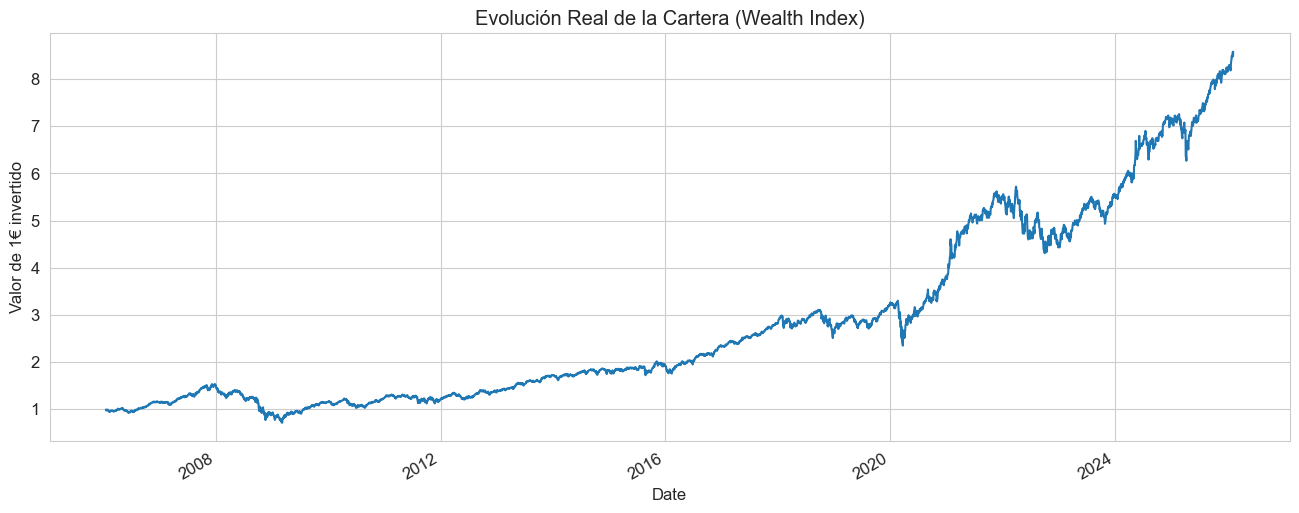

In [41]:
# Generamos el vector de pesos equiponderados para la cartera
num_activos = df_cartera.shape[1]-1
pesos = np.ones(num_activos)/num_activos

# Obtenemos la rentabilidad esperada de la cartera para cada día
mu_cartera = df_cartera.iloc[:,:-1] @ pesos
wealth_index = (1 + mu_cartera).cumprod()

wealth_index.plot(title="Evolución Real de la Cartera (Wealth Index)")
plt.ylabel("Valor de 1€ invertido")
plt.show()

Mostramos el **wealth index**. Este indicador mide cuando valdría una unidad monetaria si la invertimos en $t=0$ hasta el final del periodo $t=t$. En este caso, podemos ver que a final del periodo, si hubieramos invertido una unidad monetaria en $t=0$ habríamos multiplicado nuestra inversión por 8,58.

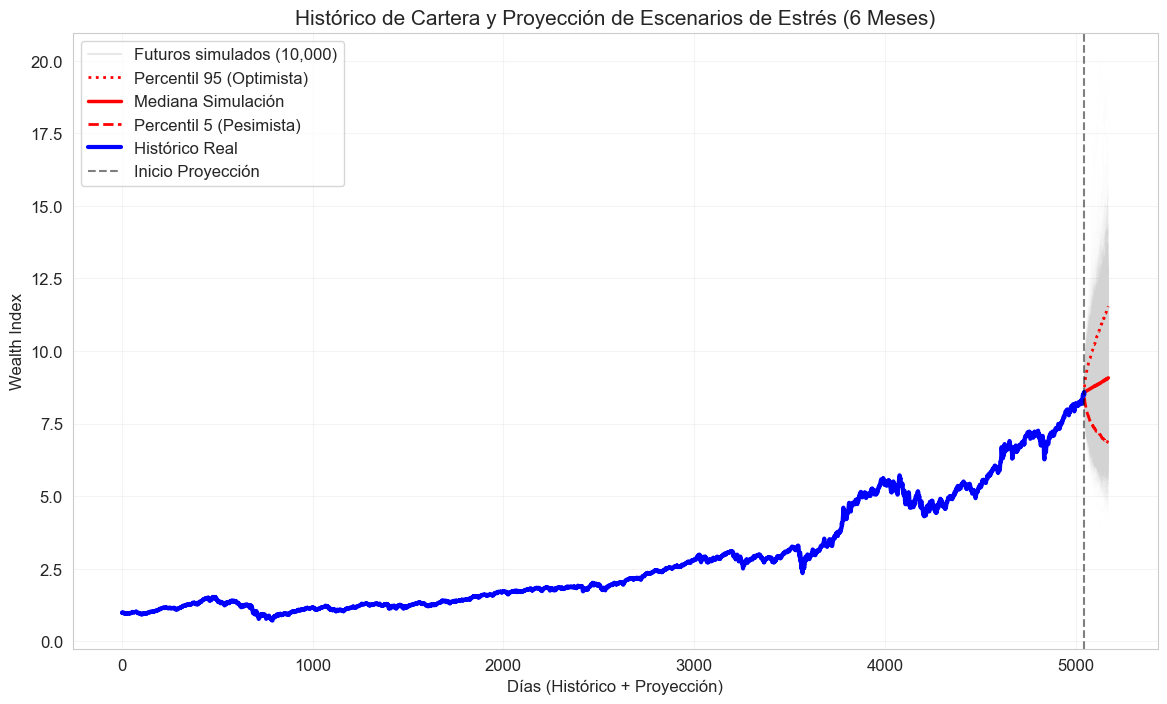

In [42]:
# --- 1. Preparación de los datos reales ---
num_activos = df_cartera.shape[1]-1
pesos = np.ones(num_activos)/num_activos
mu_cartera_real = df_cartera.iloc[:,:-1] @ pesos
wealth_index_real = (1 + mu_cartera_real).cumprod().values 

# --- 2. Preparación de los datos simulados ---
# Usamos el último valor real como punto de partida para que las líneas conecten
ultimo_valor_real = wealth_index_real[-1]

ret_cartera_sim = simulaciones.mean(axis=2) 
# Multiplicamos por el último valor real para que la serie empiece en ese nivel
wealth_index_sim = ultimo_valor_real * (1 + ret_cartera_sim).cumprod(axis=1)

# Cálculo de percentiles
p5 = np.percentile(wealth_index_sim, 5, axis=0)
p50 = np.percentile(wealth_index_sim, 50, axis=0)
p95 = np.percentile(wealth_index_sim, 95, axis=0)

# --- 3. Generación del Gráfico ---
plt.figure(figsize=(14, 8))

# Creamos los dos ejes temporales
dias_reales = np.arange(len(wealth_index_real))
# El eje simulado empieza en el último día real y suma 126 días
dias_sim = np.arange(len(wealth_index_real), len(wealth_index_real) + wealth_index_sim.shape[1])

# A) PINTAR TODAS LAS TRAYECTORIAS (Nube de futuros)
# Nota: Bajamos alpha a 0.01 porque 10,000 líneas a 0.75 taparían todo el gráfico
plt.plot(dias_sim, wealth_index_sim.T, color='lightgrey', alpha=0.01, linewidth=0.5)
plt.plot([], [], color='lightgrey', alpha=0.5, label='Futuros simulados (10,000)')

# B) Percentiles en ROJO (sobre el eje de simulación)
plt.plot(dias_sim, p95, color='red', linestyle=':', linewidth=2, label='Percentil 95 (Optimista)')
plt.plot(dias_sim, p50, color='red', linestyle='-', linewidth=2.5, label='Mediana Simulación')
plt.plot(dias_sim, p5, color='red', linestyle='--', linewidth=2, label='Percentil 5 (Pesimista)')

# C) EVOLUCIÓN REAL en AZUL (Histórico)
plt.plot(dias_reales, wealth_index_real, color='blue', linewidth=3, label='Histórico Real')

# Estética
plt.axvline(x=dias_reales[-1], color='black', linestyle='--', alpha=0.5, label='Inicio Proyección')
plt.title("Histórico de Cartera y Proyección de Escenarios de Estrés (6 Meses)", fontsize=15)
plt.xlabel("Días (Histórico + Proyección)", fontsize=12)
plt.ylabel("Wealth Index", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)

plt.show()

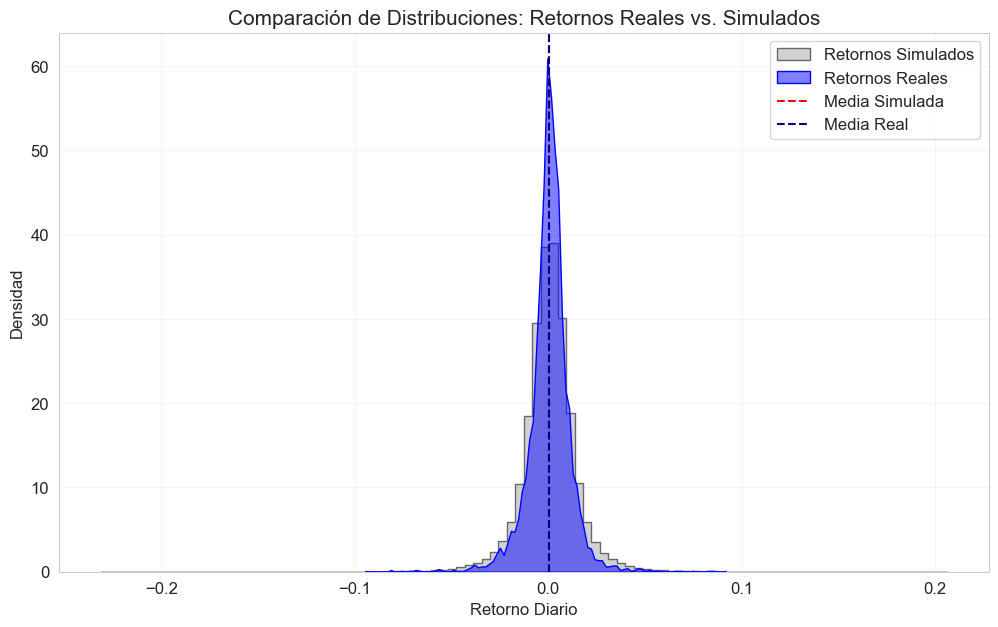

Volatilidad Diaria Real: 1.1269%
Volatilidad Diaria Simulada: 1.3902%


In [43]:
# --- 1. Preparación de los datos ---
# Retornos diarios reales de la cartera
ret_cartera_real = mu_cartera_real.values 

# Retornos diarios simulados de la cartera
# Aplanamos la matriz (10000, 126) a un solo vector de 1.260.000 datos
ret_cartera_sim_flat = ret_cartera_sim.flatten()

# --- 2. Generación del Histograma ---
plt.figure(figsize=(12, 7))

# Histograma de los datos SIMULADOS (en gris oscuro/negro)
sns.histplot(ret_cartera_sim_flat, color='dimgray', label='Retornos Simulados', 
             stat="density", element="step", alpha=0.3, bins=100)

# Histograma de los datos REALES (en azul)
sns.histplot(ret_cartera_real, color='blue', label='Retornos Reales', 
             stat="density", element="poly", alpha=0.5, bins=100)

# Añadimos líneas para las medias
plt.axvline(np.mean(ret_cartera_sim_flat), color='red', linestyle='--', label='Media Simulada')
plt.axvline(np.mean(ret_cartera_real), color='darkblue', linestyle='--', label='Media Real')

# --- 3. Formato y Estética ---
plt.title("Comparación de Distribuciones: Retornos Reales vs. Simulados", fontsize=15)
plt.xlabel("Retorno Diario", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.legend()

# Zoom en las colas (opcional, ajusta según tus datos para ver mejor el riesgo extremo)
# plt.xlim(-0.05, 0.05) 

plt.grid(True, alpha=0.2)
plt.show()

# --- 4. Estadísticos de Control ---
print(f"Volatilidad Diaria Real: {np.std(ret_cartera_real):.4%}")
print(f"Volatilidad Diaria Simulada: {np.std(ret_cartera_sim_flat):.4%}")

In [44]:
# --- 1. Preparación de vectores ---
ret_cartera_real = mu_cartera_real.values
ret_cartera_sim_flat = ret_cartera_sim.flatten()

# --- 2. Cálculo de Estadísticas ---
# Nota: La kurtosis de scipy es 'excess kurtosis' (Fisher), donde Normal = 0
stats_data = {
    'Métrica': ['Media (Mu)', 'Desviación (Sigma)', 'Skewness (Simetría)', 'Kurtosis (Exceso)'],
    'Datos Reales': [
        np.mean(ret_cartera_real),
        np.std(ret_cartera_real),
        skew(ret_cartera_real),
        kurtosis(ret_cartera_real)
    ],
    'Datos Simulados': [
        np.mean(ret_cartera_sim_flat),
        np.std(ret_cartera_sim_flat),
        skew(ret_cartera_sim_flat),
        kurtosis(ret_cartera_sim_flat)
    ]
}

df_stats = pd.DataFrame(stats_data)

# Formateo para lectura clara
df_stats['Diferencia'] = df_stats['Datos Simulados'] - df_stats['Datos Reales']
print("--- COMPARATIVA ESTADÍSTICA DE RETORNOS DIARIOS ---")
print(df_stats.to_string(index=False, formatters={
    'Datos Reales': '{:,.4}'.format if 'Media' in str(df_stats['Métrica']) else '{:,.4f}'.format,
    'Datos Simulados': '{:,.4f}'.format
}))

--- COMPARATIVA ESTADÍSTICA DE RETORNOS DIARIOS ---
            Métrica Datos Reales Datos Simulados  Diferencia
         Media (Mu)    0.0004896          0.0005   -0.000004
 Desviación (Sigma)      0.01127          0.0139    0.002633
Skewness (Simetría)      -0.1988         -0.0502    0.148573
  Kurtosis (Exceso)        9.939          5.7891   -4.149943


### 4.2.2. Reproducción de regímenes

#### Comparación Real VS Simulado (días por estado)

In [45]:
def dias_por_estado(estados_real, estados_sim):
    
    # Análisis de % de días por estado REAL
    porc_dias_crisis = (estados_real.sum()/estados_real.shape)[0]
    porc_dias_calma = (1 - porc_dias_crisis)
    real = [porc_dias_calma, porc_dias_crisis]
    
    # Análisis de % de días por estado SIMULADO
    
    porc_dias_crisis_sim = (estados_sim.sum()/(estados_sim.shape[0]*estados_sim.shape[1]))
    porc_dias_calma_sim = (1 - porc_dias_crisis_sim)
    simulado = [porc_dias_calma_sim, porc_dias_crisis_sim]
    
    resultado = np.round(pd.DataFrame((real, simulado))*100, 2)
    resultado.columns = ['% días de Calma', '% días de Crisis']
    resultado.index = ['Real', 'Simulado']
    
    return resultado

In [46]:
print('Resumen de % de días por estado')
dias_por_estado = dias_por_estado(regimes, estados_sim)
dias_por_estado

Resumen de % de días por estado


,% días de Calma,% días de Crisis
Real,69.36,30.64
Simulado,68.10,31.90


#### Comparación Real VS Simulado (duración media de cada estado)

In [47]:
def duracion_media_estado(estados_real, estados_sim):
    # Duración media REAL
    # 1. Identificamos dónde cambia el estado (0 a 1 o 1 a 0)
    indices_cambio_real = np.where(np.diff(estados_real))[0]

    # 2. Añadimos el inicio y el final para cerrar los intervalos
    puntos_corte_real = np.concatenate(([ -1], indices_cambio_real, [len(estados_real) - 1]))

    # 3. Calculamos la distancia entre cada punto de corte (las duraciones)
    duraciones_real = np.diff(puntos_corte_real)

    # 4. Clasificamos las duraciones según el estado inicial
    # Si el primer estado es 0, las duraciones en índices pares [0, 2, 4...] son de Calma
    estado_inicial = estados_real[0]
    if estado_inicial == 0:
        dur_calma_real = duraciones_real[::2].mean()
        dur_crisis_real = duraciones_real[1::2].mean() if len(duraciones_real) > 1 else 0
    else:
        dur_crisis_real = duraciones_real[::2].mean()
        dur_calma_real = duraciones_real[1::2].mean() if len(duraciones_real) > 1 else 0
    
    dur_media_real = [dur_calma_real, dur_crisis_real]
    
    # Duración media SIMULADO
    n_sims, n_pasos = estados_sim.shape
    
    # 1. Detectar cambios en toda la matriz (True donde hay salto)
    # Agregamos una columna de True al inicio para capturar la primera racha
    cambios = np.diff(estados_sim, axis=1) != 0
    inicio_filas = np.full((n_sims, 1), True) 
    mapa_cambios = np.hstack([inicio_filas, cambios])
    
    # 2. Obtener los índices (posiciones) y los IDs de fila de cada racha
    # 'filas' nos dice a qué simulación pertenece cada racha
    # 'indices' nos dice en qué día empezó esa racha
    filas, indices = np.where(mapa_cambios)
    
    # 3. Calcular duraciones
    # Calculamos la distancia entre índices de inicio de racha.
    # Para la última racha de cada fila, la distancia es hasta el final (n_pasos)
    # Usamos un truco: concatenamos un índice final por cada fila
    indices_finales = np.full(n_sims, n_pasos)
    
    # Calculamos duraciones racha a racha
    # (Esto requiere una lógica de "diff" segmentada o agrupar por el estado)
    valores_estados = estados_sim[filas, indices]
    
    # Calculamos la duración de cada racha de forma precisa
    # Desplazamos los índices para restar t+1 - t
    extremos = np.append(indices, n_pasos) # no es exacto para todas las filas
    # Mejor técnica: usar pandas groupby sobre el desenrollado
    
    df_temp = pd.DataFrame({'sim_id': filas, 'estado': valores_estados, 'inicio': indices})
    
    # Calculamos el final de cada racha como el inicio de la siguiente 
    # o el final de la simulación (n_pasos)
    df_temp['fin'] = df_temp.groupby('sim_id')['inicio'].shift(-1, fill_value=n_pasos)
    df_temp['duracion'] = df_temp['fin'] - df_temp['inicio']
    
    # 4. Agrupar por estado y simulación, y luego promediar
    resumen = df_temp.groupby(['sim_id', 'estado'])['duracion'].mean().reset_index()
    
    # Media final de todas las simulaciones
    media_final = resumen.groupby('estado')['duracion'].mean()
    dur_media_sim = [media_final[0], media_final[1]]
    
    dur_media = np.round(pd.DataFrame((dur_media_real, dur_media_sim)), 2)
    dur_media.columns = ['Duración media (Calma)', 'Duración media (Crisis)']
    dur_media.index = ['Real', 'Simulado']

    return dur_media

In [48]:
print('Resumen de duración media por estado')
duracion_media_estado = duracion_media_estado(regimes, estados_sim)
duracion_media_estado

Resumen de duración media por estado


,Duración media (Calma),Duración media (Crisis)
Real,291.67,140.55
Simulado,73.71,44.83


#### Comparación Real VS Simulado (número de cambios de estado)

In [49]:
def cambios_estado(estados_real, estados_sim):
    
    # Cambios de estado REAL
    cambios_calma_a_crisis_real = (estados_real.diff() == 1).sum()
    cambios_crisis_a_calma_real = (estados_real.diff() == -1).sum()
    num_cambios_estado_real = [cambios_calma_a_crisis_real, cambios_crisis_a_calma_real]
    
    # Cambios de estado SIMULADO
    cambios_calma_a_crisis_sim = (np.diff(estados_sim, axis=1) == 1).sum()/estados_sim.shape[0]
    cambios_crisis_a_calma_sim = (np.diff(estados_sim, axis=1) == -1).sum()/estados_sim.shape[0]
    num_cambios_estado_sim = [cambios_calma_a_crisis_sim, cambios_crisis_a_calma_sim]
    
    resultado = np.round(pd.DataFrame((num_cambios_estado_real, num_cambios_estado_sim)), 2)
    resultado.columns = ['Nº cambios de estado (Calma \u2192 Crisis)', 'Nº cambios de estado (Crisis \u2192 Calma)']
    resultado.index = ['Real', 'Simulado']
    
    return resultado

In [50]:
print('Resumen de número de cambio de estado')
cambios_estado = cambios_estado(regimes, estados_sim)
cambios_estado

Resumen de número de cambio de estado


,Nº cambios de estado (Calma → Crisis),Nº cambios de estado (Crisis → Calma)
Real,11.00,11.00
Simulado,0.68,0.66


### 4.2.3. Reproducción de riesgo y dependencia

#### Comparación comportamiento de la cartera: datos reales vs simulados

In [51]:
def metricas_comparativas(ret_real, ret_sim_matriz):
    # ret_real: vector (n_dias,)
    # ret_sim_matriz: matriz (n_sims, n_dias)
    
    def obtener_stats(rets):
        # 1. Volatilidad Anualizada
        vol_anual = np.std(rets) * np.sqrt(252)
        vol_diaria = np.std(rets)
        
        # 2. VaR 99% y CVaR 99% (Retorno diario)
        var_99 = np.percentile(rets, 1)
        cvar_99 = rets[rets <= var_99].mean()
        
        # 3. Max Drawdown
        wealth = (1 + rets).cumprod()
        peak = np.maximum.accumulate(wealth)
        dd = (wealth - peak) / peak
        mdd = np.min(dd)
        
        return [vol_diaria, vol_anual, mdd, var_99, cvar_99]

    # --- Cálculo Real ---
    stats_real = obtener_stats(ret_real)

    # --- Cálculo Simulado (Media de todas las trayectorias) ---
    # Calculamos las métricas para cada una de las n_sims
    list_stats_sim = []
    for i in range(ret_sim_matriz.shape[0]):
        list_stats_sim.append(obtener_stats(ret_sim_matriz[i, :]))
    df_sims = pd.DataFrame(list_stats_sim)
    
    stats_sim_media = df_sims.mean().tolist()
    stats_sim_std = df_sims.std().tolist() # Para ver la dispersión de la simulación

    # --- Formateo Final ---
    indices = ['Volatilidad diaria', 'Volatilidad anual', 'Max Drawdown', 'VaR 99% (diario)', 'CVaR 99% (diario)']
    tabla = pd.DataFrame({
        'Retornos reales': stats_real,
        'Retornos simulados (Media)': stats_sim_media,
        'Error Simulación (Std)': stats_sim_std
    }, index=indices)

    return tabla.round(4)

In [52]:
resultado_riesgo = metricas_comparativas(mu_cartera, ret_cartera_sim)
resultado_riesgo

,Retornos reales,Retornos simulados (Media),Error Simulación (Std)
Volatilidad diaria,0.0113,0.0131,0.0043
Volatilidad anual,0.1789,0.2087,0.0688
Max Drawdown,-0.5320,-0.1378,0.0794
VaR 99% (diario),-0.0323,-0.0323,0.0132
CVaR 99% (diario),-0.0471,-0.0386,0.0168


Podemos apreciar que el simulador, en este caso, es menos conservador que la realidad. Los indicadores de riesgo en los retornos reales "saltan" mucho antes de lo que lo hacen con los datos simulados.

#### Verificación del estado de estrés del simulador

In [53]:
def verificar_simulador_estres(simulaciones_3d, estados_sim_2d):
    vols_crisis_sims, corrs_crisis_sims = [], []
    vols_calma_sims, corrs_calma_sims = [], []

    n_sims = simulaciones_3d.shape[0]
    n_activos = simulaciones_3d.shape[2]

    for i in range(n_sims):
        retornos_i = simulaciones_3d[i]
        estados_i = estados_sim_2d[i]
        ret_cartera_i = retornos_i.mean(axis=1)
        
        mask_crisis = (estados_i == 1)
        mask_calma = (estados_i == 0)
        
        # --- VALIDACIÓN CRISIS (Mínimo 2 días para poder correlacionar) ---
        if mask_crisis.sum() > 1:
            vols_crisis_sims.append(np.std(ret_cartera_i[mask_crisis]) * np.sqrt(252))
            c_mat = np.corrcoef(retornos_i[mask_crisis], rowvar=False)
            # Solo añadimos si la matriz no contiene NaNs
            if not np.isnan(c_mat).any():
                avg_c = (np.sum(c_mat) - n_activos) / (n_activos**2 - n_activos)
                corrs_crisis_sims.append(avg_c)
            
        # --- VALIDACIÓN CALMA ---
        if mask_calma.sum() > 1:
            vols_calma_sims.append(np.std(ret_cartera_i[mask_calma]) * np.sqrt(252))
            c_mat_calma = np.corrcoef(retornos_i[mask_calma], rowvar=False)
            if not np.isnan(c_mat_calma).any():
                avg_c_calma = (np.sum(c_mat_calma) - n_activos) / (n_activos**2 - n_activos)
                corrs_calma_sims.append(avg_c_calma)

    # 3. Resultado Final Agregado usando np.nanmean
    # np.nanmean ignora los valores nulos si los hubiera
    reporte = pd.DataFrame({
        'Métrica': ['Volatilidad Media (Anual)', 'Correlación Media Activos'],
        'Estado Calma': [
            np.nanmean(vols_calma_sims) if vols_calma_sims else 0, 
            np.nanmean(corrs_calma_sims) if corrs_calma_sims else 0
        ],
        'Estado Crisis': [
            np.nanmean(vols_crisis_sims) if vols_crisis_sims else 0, 
            np.nanmean(corrs_crisis_sims) if corrs_crisis_sims else 0
        ]
    })
    
    # Manejo de división por cero si Calma es 0 (como en los escenarios de estrés)
    reporte['Incremento (%)'] = 0.0
    mask_calma_no_zero = reporte['Estado Calma'] != 0
    reporte.loc[mask_calma_no_zero, 'Incremento (%)'] = (
        (reporte['Estado Crisis'] / reporte['Estado Calma']) - 1
    ) * 100
    
    return reporte.round(4)

In [54]:
verificar_simulador = verificar_simulador_estres(simulaciones, estados_sim)
verificar_simulador

,Métrica,Estado Calma,Estado Crisis,Incremento (%)
0,Volatilidad Media (Anual),0.1328,0.3235,143.5792
1,Correlación Media Activos,0.1838,0.2786,51.5801


En la tabla superior se muestra como en estados de crisis, las simulaciones tienen una mayor volatilidad y correlación de los activos, haciendo que la diversificación no sea tan eficaz.

## **Fase 5: Escenarios de Estrés**

**Objetivo**: Romper la cartera. Para cada escenario, realiza 10.000 simulaciones durante 6 meses y valida los datos como en el apartado anterior

- **Escenario 1 (Estanflación 2022)**.
- **Escenario 2 (Crisis de Crédito – 2008)**.
- Diseña algún **escenario alternativo** y justifica, económicamente, el mismo.
- **Cálculo**: VaR 99% y Expected Shortfall (CVaR) bajo estos escenarios forzados.

Adaptamos la función que hemos definido antes para generar cada una de las simulaciones. En este caso, no hay alternancia de estados del mercado.

In [55]:
def simular_retornos_periodo(n_dias, cop_periodo, params_periodo):
    
    n_dias = n_dias
    n_activos = 16
    retornos_finales = np.zeros((n_dias, n_activos))

    # Cálculo mediante cópulas
    u_periodo = cop_periodo.random(n_dias).values
    for i in range(n_activos):
        retornos_finales[:, i] = t.ppf(u_periodo[:, i], df=cop_periodo.params.df, 
                                               loc=params_periodo['mu'][i], 
                                               scale=params_periodo['sigma'][i])
    
    return retornos_finales

Adaptamos la función que agrupa todas las simulaciones de Monte Carlo en un dataframe.

In [56]:
def simulaciones_periodo(n_sims, n_dias, n_activos, cop_periodo, params_periodo):
    # Pre-asignamos el espacio: (10000 trayectorias, X días, 16 activos)
    # Esto ocupa memoria de forma contigua, lo que es mucho más rápido
    resultados = np.zeros((n_sims, n_dias, n_activos))
    
    print(f"Iniciando {n_sims} simulaciones de {n_dias} días...")
    
    for sim in range(n_sims):
        # 1. Generamos la matriz de retornos (dias x activos) para esta trayectoria
        # Nota: He llamado a tu función simular_retornos o generar_retornos_dia
        # pasándole el path de estados completo
        retornos_trayectoria = simular_retornos_periodo(n_dias, cop_periodo, params_periodo)        
        # 3. Guardamos la matriz completa en nuestra variable 3D
        resultados[sim, :, :] = retornos_trayectoria
        
        # Monitor de progreso
        if (sim + 1) % 1000 == 0:
            print(f"Progreso: {sim + 1}/{n_sims} trayectorias completadas.")
            
    return resultados

## 5.1. Escenario 1 (Estanflación 2022).

In [57]:
# Seleccionamos los datos
escenario_2022 = df_cartera.iloc[4020:4245].iloc[:,:-1]

In [58]:
# Para cargarlos en el futuro:
with open('modelos_copulas_2022_60.pkl', 'rb') as f:
    data = pickle.load(f)
    cop_2022 = data['copula_2022']
    
# Calculamos los parámetros marginales
params_2022 = {'mu': escenario_2022.mean().values, 'sigma': escenario_2022.std().values}

In [59]:
# 2. Ajuste de Cópula t-Student para el escenario de estanflación
#u_2022 = get_pseudo_obs(escenario_2022)
#cop_2022 = StudentCopula(dim=u_2022.shape[1])
#cop_2022.fit(u_2022)

# Calculamos los parámetros marginales
#params_2022 = {'mu': escenario_2022.mean().values, 'sigma': escenario_2022.std().values}

In [60]:
# Guardar los modelos entrenados
#with open('modelos_copulas_2022_60.pkl', 'wb') as f:
    #pickle.dump({'copula_2022': cop_2022}, f)

In [61]:
simulaciones_2022 = simulaciones_periodo(10000, 126, escenario_2022.shape[1], cop_2022, params_2022)

Iniciando 10000 simulaciones de 126 días...
Progreso: 1000/10000 trayectorias completadas.
Progreso: 2000/10000 trayectorias completadas.
Progreso: 3000/10000 trayectorias completadas.
Progreso: 4000/10000 trayectorias completadas.
Progreso: 5000/10000 trayectorias completadas.
Progreso: 6000/10000 trayectorias completadas.
Progreso: 7000/10000 trayectorias completadas.
Progreso: 8000/10000 trayectorias completadas.
Progreso: 9000/10000 trayectorias completadas.
Progreso: 10000/10000 trayectorias completadas.


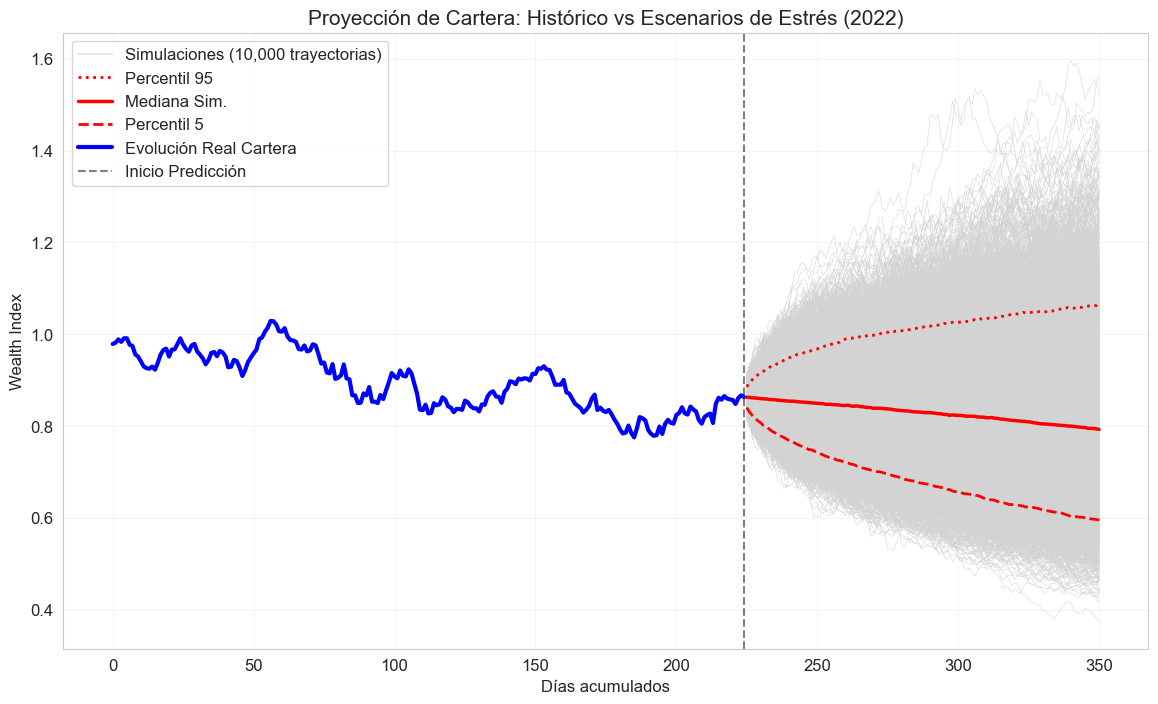

In [62]:
# --- 1. Preparación de los datos reales ---
num_activos = escenario_2022.shape[1]
pesos = np.ones(num_activos)/num_activos
mu_cartera_2022 = escenario_2022 @ pesos
wealth_index_2022 = (1 + mu_cartera_2022).cumprod().values

# --- 2. Preparación de los datos simulados ---
ret_cartera_sim_2022 = simulaciones_2022.mean(axis=2) 
# Importante: Las simulaciones deben partir del último valor real para que el gráfico enganche
ultimo_valor_real = wealth_index_2022[-1]
wealth_index_sim_2022 = ultimo_valor_real * (1 + ret_cartera_sim_2022).cumprod(axis=1)

# Cálculo de percentiles
p5 = np.percentile(wealth_index_sim_2022, 5, axis=0)
p50 = np.percentile(wealth_index_sim_2022, 50, axis=0)
p95 = np.percentile(wealth_index_sim_2022, 95, axis=0)

# --- 3. Generación del Gráfico ---
plt.figure(figsize=(14, 8))

# Definimos los dos ejes temporales
dias_reales = np.arange(len(wealth_index_2022))
# El eje de simulación empieza donde acaba el real
dias_simulados = np.arange(len(wealth_index_2022), len(wealth_index_2022) + wealth_index_sim_2022.shape[1])

# A) PINTAR TODAS LAS TRAYECTORIAS (Usamos dias_simulados)
# Bajé el alpha a 0.05 o 0.1 porque 0.75 con 10,000 líneas se verá como un bloque sólido
plt.plot(dias_simulados, wealth_index_sim_2022.T, color='lightgrey', alpha=0.75, linewidth=0.5)
plt.plot([], [], color='lightgrey', alpha=0.5, label='Simulaciones (10,000 trayectorias)')

# B) Percentiles en ROJO
plt.plot(dias_simulados, p95, color='red', linestyle=':', linewidth=2, label='Percentil 95')
plt.plot(dias_simulados, p50, color='red', linestyle='-', linewidth=2.5, label='Mediana Sim.')
plt.plot(dias_simulados, p5, color='red', linestyle='--', linewidth=2, label='Percentil 5')

# C) EVOLUCIÓN REAL en AZUL
plt.plot(dias_reales, wealth_index_2022, color='blue', linewidth=3, label='Evolución Real Cartera')

# Estética
plt.axvline(x=dias_reales[-1], color='black', linestyle='--', alpha=0.5, label='Inicio Predicción')
plt.title("Proyección de Cartera: Histórico vs Escenarios de Estrés (2022)", fontsize=15)
plt.xlabel("Días acumulados", fontsize=12)
plt.ylabel("Wealth Index", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)

plt.show()

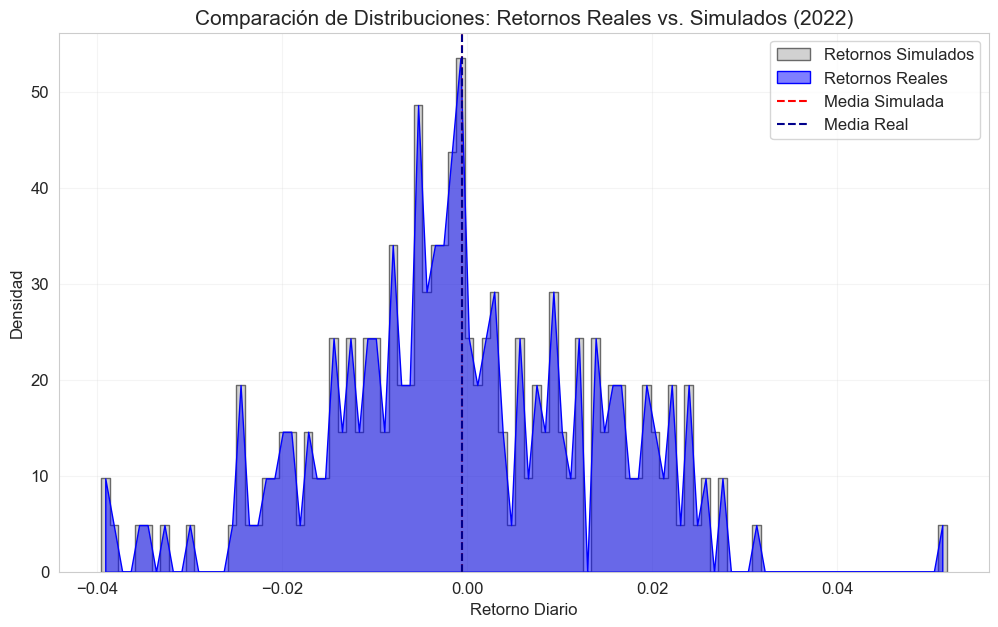

Volatilidad Diaria Real: 1.4623%
Volatilidad Diaria Simulada: 1.4623%


In [63]:
# --- 1. Preparación de los datos ---
# Retornos diarios reales de la cartera
ret_cartera_2022 = mu_cartera_2022.values 

# Retornos diarios simulados de la cartera
# Aplanamos la matriz (10000, 126) a un solo vector de 1.260.000 datos
ret_cartera_sim_flat_2022 = ret_cartera_2022.flatten()

# --- 2. Generación del Histograma ---
plt.figure(figsize=(12, 7))

# Histograma de los datos SIMULADOS (en gris oscuro/negro)
sns.histplot(ret_cartera_sim_flat_2022, color='dimgray', label='Retornos Simulados', 
             stat="density", element="step", alpha=0.3, bins=100)

# Histograma de los datos REALES (en azul)
sns.histplot(ret_cartera_2022, color='blue', label='Retornos Reales', 
             stat="density", element="poly", alpha=0.5, bins=100)

# Añadimos líneas para las medias
plt.axvline(np.mean(ret_cartera_sim_flat_2022), color='red', linestyle='--', label='Media Simulada')
plt.axvline(np.mean(ret_cartera_2022), color='darkblue', linestyle='--', label='Media Real')

# --- 3. Formato y Estética ---
plt.title("Comparación de Distribuciones: Retornos Reales vs. Simulados (2022)", fontsize=15)
plt.xlabel("Retorno Diario", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.legend()

# Zoom en las colas (opcional, ajusta según tus datos para ver mejor el riesgo extremo)
# plt.xlim(-0.05, 0.05) 

plt.grid(True, alpha=0.2)
plt.show()

# --- 4. Estadísticos de Control ---
print(f"Volatilidad Diaria Real: {np.std(ret_cartera_2022):.4%}")
print(f"Volatilidad Diaria Simulada: {np.std(ret_cartera_sim_flat_2022):.4%}")

In [64]:
resultado_riesgo_2022 = metricas_comparativas(escenario_2022.mean(axis = 1), simulaciones_2022.mean(axis =2))
resultado_riesgo_2022

,Retornos reales,Retornos simulados (Media),Error Simulación (Std)
Volatilidad diaria,0.0146,0.0159,0.0011
Volatilidad anual,0.2321,0.2521,0.0174
Max Drawdown,-0.2466,-0.2116,0.0803
VaR 99% (diario),-0.0379,-0.0365,0.0052
CVaR 99% (diario),-0.0389,-0.0408,0.0065


## 5.2. Escenario 2 (Crisis de Crédito – 2008).

In [65]:
escenario_2008 = df_cartera.iloc[415:1003,:-1]
#escenario_2008 = df_cartera.iloc[415:820,:-1]      ###### 789 índice con el mínimo del sp500

In [66]:
# Para cargarlos en el futuro:
with open('modelos_copulas_2008_60.pkl', 'rb') as f:
    data = pickle.load(f)
    cop_2008 = data['copula_2008']
    
# Calculamos los parámetros marginales
params_2008 = {'mu': escenario_2008.mean().values, 'sigma': escenario_2008.std().values}

In [67]:
# 2. Ajuste de Cópula t-Student para el escenario de estanflación
#u_2008 = get_pseudo_obs(escenario_2008)
#cop_2008 = StudentCopula(dim=u_2008.shape[1])
#cop_2008.fit(u_2008)

# Calculamos los parámetros marginales
#params_2008 = {'mu': escenario_2008.mean().values, 'sigma': escenario_2008.std().values}

In [68]:
# Guardar los modelos entrenados
#with open('modelos_copulas_2008_60.pkl', 'wb') as f:
    #pickle.dump({'copula_2008': cop_2008}, f)

In [69]:
simulaciones_2008 = simulaciones_periodo(10000, 126, escenario_2008.shape[1], cop_2008, params_2008)

Iniciando 10000 simulaciones de 126 días...
Progreso: 1000/10000 trayectorias completadas.
Progreso: 2000/10000 trayectorias completadas.
Progreso: 3000/10000 trayectorias completadas.
Progreso: 4000/10000 trayectorias completadas.
Progreso: 5000/10000 trayectorias completadas.
Progreso: 6000/10000 trayectorias completadas.
Progreso: 7000/10000 trayectorias completadas.
Progreso: 8000/10000 trayectorias completadas.
Progreso: 9000/10000 trayectorias completadas.
Progreso: 10000/10000 trayectorias completadas.


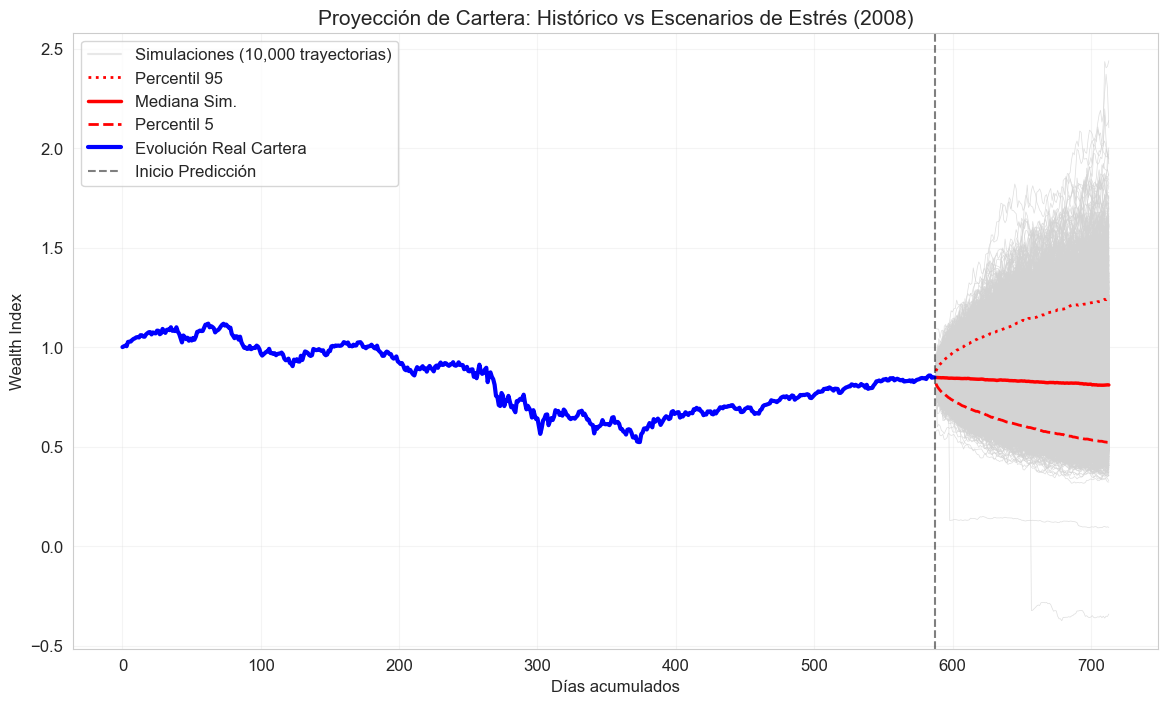

In [70]:
# --- 1. Preparación de los datos reales ---
num_activos = escenario_2008.shape[1]
pesos = np.ones(num_activos)/num_activos
mu_cartera_2008 = escenario_2008 @ pesos
wealth_index_2008 = (1 + mu_cartera_2008).cumprod().values

# --- 2. Preparación de los datos simulados ---
ret_cartera_sim_2008 = simulaciones_2008.mean(axis=2) 
# Importante: Las simulaciones deben partir del último valor real para que el gráfico enganche
ultimo_valor_real = wealth_index_2008[-1]
wealth_index_sim_2008 = ultimo_valor_real * (1 + ret_cartera_sim_2008).cumprod(axis=1)

# Cálculo de percentiles
p5 = np.percentile(wealth_index_sim_2008, 5, axis=0)
p50 = np.percentile(wealth_index_sim_2008, 50, axis=0)
p95 = np.percentile(wealth_index_sim_2008, 95, axis=0)

# --- 3. Generación del Gráfico ---
plt.figure(figsize=(14, 8))

# Definimos los dos ejes temporales
dias_reales = np.arange(len(wealth_index_2008))
# El eje de simulación empieza donde acaba el real
dias_simulados = np.arange(len(wealth_index_2008), len(wealth_index_2008) + wealth_index_sim_2008.shape[1])

# A) PINTAR TODAS LAS TRAYECTORIAS (Usamos dias_simulados)
# Bajé el alpha a 0.05 o 0.1 porque 0.75 con 10,000 líneas se verá como un bloque sólido
plt.plot(dias_simulados, wealth_index_sim_2008.T, color='lightgrey', alpha=0.75, linewidth=0.5)
plt.plot([], [], color='lightgrey', alpha=0.5, label='Simulaciones (10,000 trayectorias)')

# B) Percentiles en ROJO
plt.plot(dias_simulados, p95, color='red', linestyle=':', linewidth=2, label='Percentil 95')
plt.plot(dias_simulados, p50, color='red', linestyle='-', linewidth=2.5, label='Mediana Sim.')
plt.plot(dias_simulados, p5, color='red', linestyle='--', linewidth=2, label='Percentil 5')

# C) EVOLUCIÓN REAL en AZUL
plt.plot(dias_reales, wealth_index_2008, color='blue', linewidth=3, label='Evolución Real Cartera')

# Estética
plt.axvline(x=dias_reales[-1], color='black', linestyle='--', alpha=0.5, label='Inicio Predicción')
plt.title("Proyección de Cartera: Histórico vs Escenarios de Estrés (2008)", fontsize=15)
plt.xlabel("Días acumulados", fontsize=12)
plt.ylabel("Wealth Index", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)

plt.show()

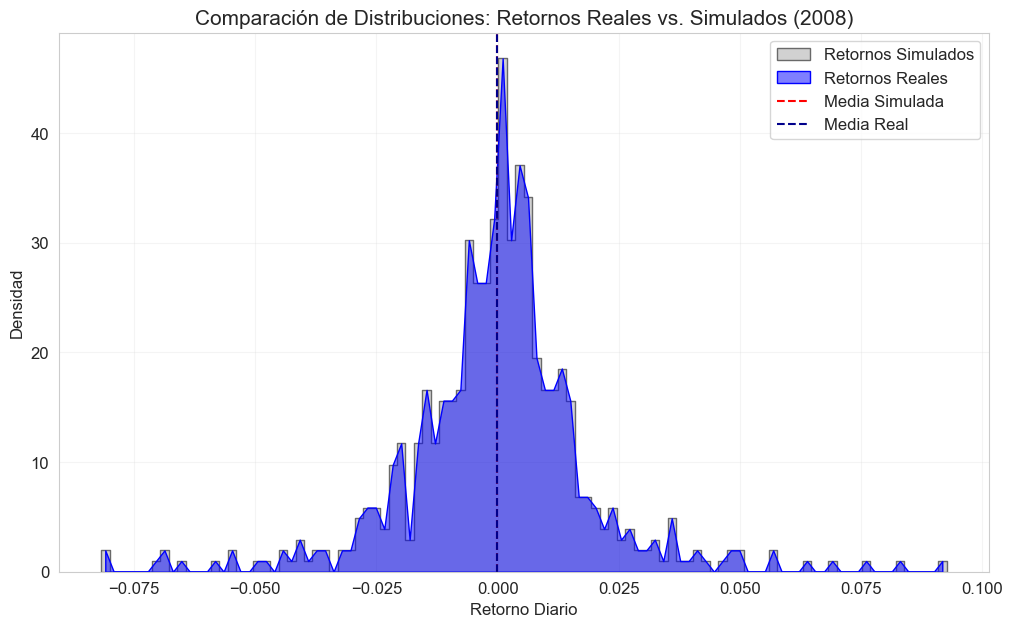

Volatilidad Diaria Real: 1.8864%
Volatilidad Diaria Simulada: 1.8864%


In [71]:
# --- 1. Preparación de los datos ---
# Retornos diarios reales de la cartera
ret_cartera_2008 = mu_cartera_2008.values 

# Retornos diarios simulados de la cartera
# Aplanamos la matriz (10000, 126) a un solo vector de 1.260.000 datos
ret_cartera_sim_flat_2008 = ret_cartera_2008.flatten()

# --- 2. Generación del Histograma ---
plt.figure(figsize=(12, 7))

# Histograma de los datos SIMULADOS (en gris oscuro/negro)
sns.histplot(ret_cartera_sim_flat_2008, color='dimgray', label='Retornos Simulados', 
             stat="density", element="step", alpha=0.3, bins=100)

# Histograma de los datos REALES (en azul)
sns.histplot(ret_cartera_2008, color='blue', label='Retornos Reales', 
             stat="density", element="poly", alpha=0.5, bins=100)

# Añadimos líneas para las medias
plt.axvline(np.mean(ret_cartera_sim_flat_2008), color='red', linestyle='--', label='Media Simulada')
plt.axvline(np.mean(ret_cartera_2008), color='darkblue', linestyle='--', label='Media Real')

# --- 3. Formato y Estética ---
plt.title("Comparación de Distribuciones: Retornos Reales vs. Simulados (2008)", fontsize=15)
plt.xlabel("Retorno Diario", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.legend()

# Zoom en las colas (opcional, ajusta según tus datos para ver mejor el riesgo extremo)
# plt.xlim(-0.05, 0.05) 

plt.grid(True, alpha=0.2)
plt.show()

# --- 4. Estadísticos de Control ---
print(f"Volatilidad Diaria Real: {np.std(ret_cartera_2008):.4%}")
print(f"Volatilidad Diaria Simulada: {np.std(ret_cartera_sim_flat_2008):.4%}")

In [72]:
resultado_riesgo_2008 = metricas_comparativas(escenario_2008.mean(axis = 1), simulaciones_2008.mean(axis =2))
resultado_riesgo_2008

,Retornos reales,Retornos simulados (Media),Error Simulación (Std)
Volatilidad diaria,0.0189,0.0236,0.0027
Volatilidad anual,0.2995,0.3742,0.0423
Max Drawdown,-0.5320,-0.2694,0.1009
VaR 99% (diario),-0.0596,-0.0570,0.0117
CVaR 99% (diario),-0.0725,-0.0679,0.0195


## 5.3. Diseña algún escenario alternativo y justifica, económicamente, el mismo.

In [73]:
escenario_2020 = df_cartera.iloc[3548:3822,:-1]

In [74]:
# Para cargarlos en el futuro:
with open('modelos_copulas_2020_60.pkl', 'rb') as f:
    data = pickle.load(f)
    cop_2020 = data['copula_2020']
    
# Calculamos los parámetros marginales
params_2020 = {'mu': escenario_2020.mean().values, 'sigma': escenario_2020.std().values}

In [75]:
# 2. Ajuste de Cópula t-Student para el escenario de estanflación
#u_2020 = get_pseudo_obs(escenario_2020)
#cop_2020 = StudentCopula(dim=u_2020.shape[1])
#cop_2020.fit(u_2020)

# Calculamos los parámetros marginales
#params_2020 = {'mu': escenario_2020.mean().values, 'sigma': escenario_2020.std().values}

In [76]:
# Guardar los modelos entrenados
#with open('modelos_copulas_2020_60.pkl', 'wb') as f:
    #pickle.dump({'copula_2020': cop_2020}, f)

In [77]:
simulaciones_2020 = simulaciones_periodo(10000, 126, escenario_2020.shape[1], cop_2020, params_2020)

Iniciando 10000 simulaciones de 126 días...
Progreso: 1000/10000 trayectorias completadas.
Progreso: 2000/10000 trayectorias completadas.
Progreso: 3000/10000 trayectorias completadas.
Progreso: 4000/10000 trayectorias completadas.
Progreso: 5000/10000 trayectorias completadas.
Progreso: 6000/10000 trayectorias completadas.
Progreso: 7000/10000 trayectorias completadas.
Progreso: 8000/10000 trayectorias completadas.
Progreso: 9000/10000 trayectorias completadas.
Progreso: 10000/10000 trayectorias completadas.


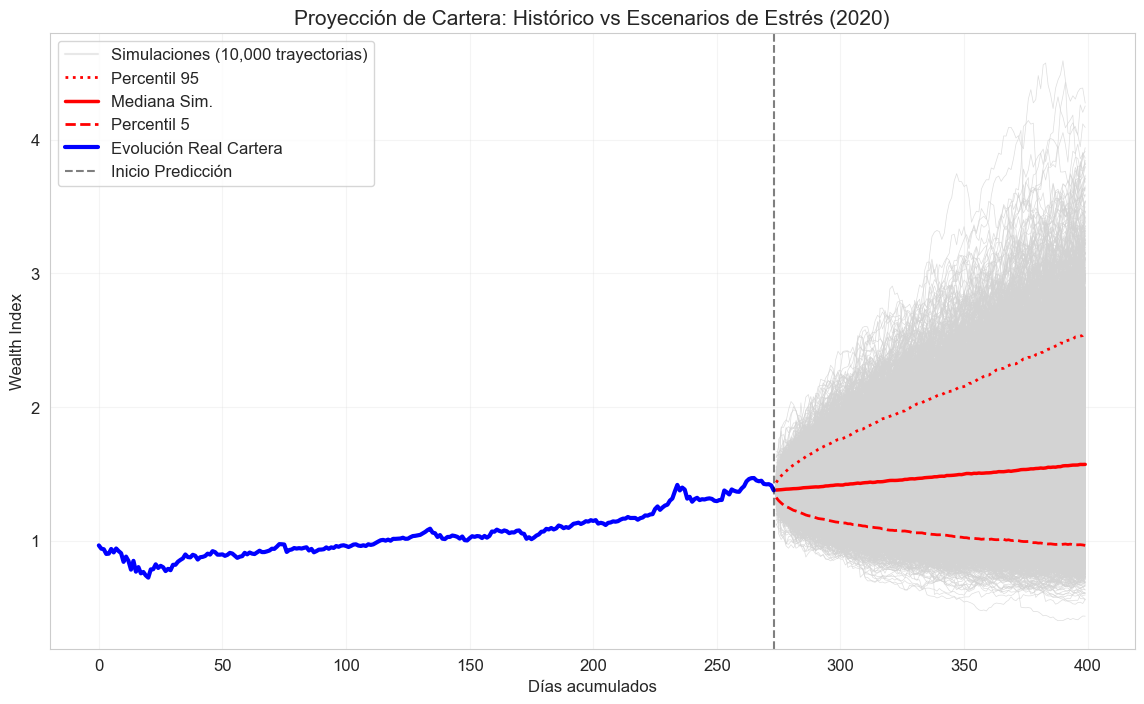

In [78]:
# --- 1. Preparación de los datos reales ---
num_activos = escenario_2020.shape[1]
pesos = np.ones(num_activos)/num_activos
mu_cartera_2020 = escenario_2020 @ pesos
wealth_index_2020 = (1 + mu_cartera_2020).cumprod().values

# --- 2. Preparación de los datos simulados ---
ret_cartera_sim_2020 = simulaciones_2020.mean(axis=2) 
# Importante: Las simulaciones deben partir del último valor real para que el gráfico enganche
ultimo_valor_real = wealth_index_2020[-1]
wealth_index_sim_2020 = ultimo_valor_real * (1 + ret_cartera_sim_2020).cumprod(axis=1)

# Cálculo de percentiles
p5 = np.percentile(wealth_index_sim_2020, 5, axis=0)
p50 = np.percentile(wealth_index_sim_2020, 50, axis=0)
p95 = np.percentile(wealth_index_sim_2020, 95, axis=0)

# --- 3. Generación del Gráfico ---
plt.figure(figsize=(14, 8))

# Definimos los dos ejes temporales
dias_reales = np.arange(len(wealth_index_2020))
# El eje de simulación empieza donde acaba el real
dias_simulados = np.arange(len(wealth_index_2020), len(wealth_index_2020) + wealth_index_sim_2020.shape[1])

# A) PINTAR TODAS LAS TRAYECTORIAS (Usamos dias_simulados)
# Bajé el alpha a 0.05 o 0.1 porque 0.75 con 10,000 líneas se verá como un bloque sólido
plt.plot(dias_simulados, wealth_index_sim_2020.T, color='lightgrey', alpha=0.75, linewidth=0.5)
plt.plot([], [], color='lightgrey', alpha=0.5, label='Simulaciones (10,000 trayectorias)')

# B) Percentiles en ROJO
plt.plot(dias_simulados, p95, color='red', linestyle=':', linewidth=2, label='Percentil 95')
plt.plot(dias_simulados, p50, color='red', linestyle='-', linewidth=2.5, label='Mediana Sim.')
plt.plot(dias_simulados, p5, color='red', linestyle='--', linewidth=2, label='Percentil 5')

# C) EVOLUCIÓN REAL en AZUL
plt.plot(dias_reales, wealth_index_2020, color='blue', linewidth=3, label='Evolución Real Cartera')

# Estética
plt.axvline(x=dias_reales[-1], color='black', linestyle='--', alpha=0.5, label='Inicio Predicción')
plt.title("Proyección de Cartera: Histórico vs Escenarios de Estrés (2020)", fontsize=15)
plt.xlabel("Días acumulados", fontsize=12)
plt.ylabel("Wealth Index", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)

plt.show()

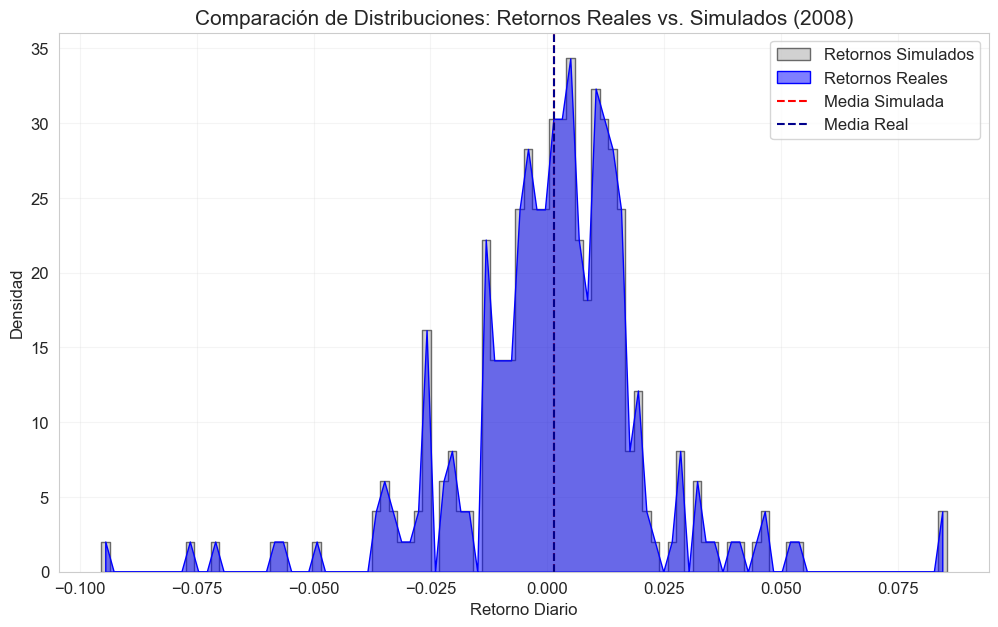

Volatilidad Diaria Real: 2.0042%
Volatilidad Diaria Simulada: 2.0042%


In [79]:
# --- 1. Preparación de los datos ---
# Retornos diarios reales de la cartera
ret_cartera_2020 = mu_cartera_2020.values 

# Retornos diarios simulados de la cartera
# Aplanamos la matriz (10000, 126) a un solo vector de 1.260.000 datos
ret_cartera_sim_flat_2020 = ret_cartera_2020.flatten()

# --- 2. Generación del Histograma ---
plt.figure(figsize=(12, 7))

# Histograma de los datos SIMULADOS (en gris oscuro/negro)
sns.histplot(ret_cartera_sim_flat_2020, color='dimgray', label='Retornos Simulados', 
             stat="density", element="step", alpha=0.3, bins=100)

# Histograma de los datos REALES (en azul)
sns.histplot(ret_cartera_2020, color='blue', label='Retornos Reales', 
             stat="density", element="poly", alpha=0.5, bins=100)

# Añadimos líneas para las medias
plt.axvline(np.mean(ret_cartera_sim_flat_2020), color='red', linestyle='--', label='Media Simulada')
plt.axvline(np.mean(ret_cartera_2020), color='darkblue', linestyle='--', label='Media Real')

# --- 3. Formato y Estética ---
plt.title("Comparación de Distribuciones: Retornos Reales vs. Simulados (2008)", fontsize=15)
plt.xlabel("Retorno Diario", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.legend()

# Zoom en las colas (opcional, ajusta según tus datos para ver mejor el riesgo extremo)
# plt.xlim(-0.05, 0.05) 

plt.grid(True, alpha=0.2)
plt.show()

# --- 4. Estadísticos de Control ---
print(f"Volatilidad Diaria Real: {np.std(ret_cartera_2020):.4%}")
print(f"Volatilidad Diaria Simulada: {np.std(ret_cartera_sim_flat_2020):.4%}")

In [80]:
resultado_riesgo_2020 = metricas_comparativas(escenario_2020.mean(axis = 1), simulaciones_2020.mean(axis =2))
resultado_riesgo_2020

,Retornos reales,Retornos simulados (Media),Error Simulación (Std)
Volatilidad diaria,0.0200,0.0259,0.0030
Volatilidad anual,0.3182,0.4107,0.0471
Max Drawdown,-0.2501,-0.2404,0.0928
VaR 99% (diario),-0.0615,-0.0618,0.0140
CVaR 99% (diario),-0.0810,-0.0750,0.0220


In [86]:
estados_sim.sum()/(estados_sim.shape[0]*estados_sim.shape[1])

np.float64(0.3189563492063492)